In [1]:
# ---- Standard library ----
import os
import time
from pathlib import Path
from random import randrange   # do_ROC (classifiers_functions)

# ---- Core scientific stack ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import plotly.graph_objects as go
import seaborn as sns
from matplotlib_venn import venn2, venn2_circles

# ---- Statistics ----
from scipy import stats
from scipy.stats import chi2      # LR_loglike (classifiers_functions)
import statsmodels.stats.multitest

# ---- Preprocessing & feature selection ----
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.feature_selection import RFE, RFECV

# ---- Models ----
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier

# ---- Validation & metrics ----
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneOut, LeaveOneGroupOut, cross_val_predict
)
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    log_loss                           # deviance (classifiers_functions)
)

logo = LeaveOneGroupOut()  # used inside classifiers_functions.ipynb

%matplotlib inline

# Helper functions (keep classifiers_functions.ipynb in the same folder as this notebook)
%run classifiers_functions.ipynb

# Data Interpretation Part 1

## Load in data for this section, again feel free to use your own data.

In [2]:
# Data load in
# change filepath
file = r"breast_ROI_labeled.csv"
tmp_train, Data_train, mz = load_data(file,features = None)
tmp_train

data already has the same spectral variables


,Sample,Class,102.058,102.063,102.065,107.038,107.04,107.045,108.023,108.025,...,1161.739,1165.751,1171.61,1172.612,1173.612,1175.641,1189.658,1190.665,1194.579,1199.563
0,pixel_1_1,Background,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,107.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,pixel_1_2,Background,0.0,0.0,0.0,0.0,0.0,0.0,133.0,133.0,...,0.0,0.0,107.0,193.0,0.0,0.0,67.0,0.0,0.0,0.0
2,pixel_1_3,Background,0.0,0.0,0.0,0.0,0.0,0.0,82.0,82.0,...,0.0,0.0,163.0,0.0,0.0,0.0,125.0,0.0,0.0,0.0
3,pixel_1_4,Background,0.0,0.0,0.0,0.0,0.0,0.0,96.0,96.0,...,0.0,0.0,332.0,0.0,0.0,0.0,0.0,0.0,82.0,0.0
4,pixel_1_5,Background,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,93.0,0.0,0.0,0.0,75.0,0.0,98.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26545,pixel_177_146,Background,0.0,0.0,0.0,0.0,0.0,0.0,52.0,52.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26546,pixel_177_147,Background,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,92.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26547,pixel_177_148,Background,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,48.0,0.0,0.0,0.0,0.0,0.0,0.0
26548,pixel_177_149,Background,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## This dataset also has annotation metadata, let's see what it looks like:

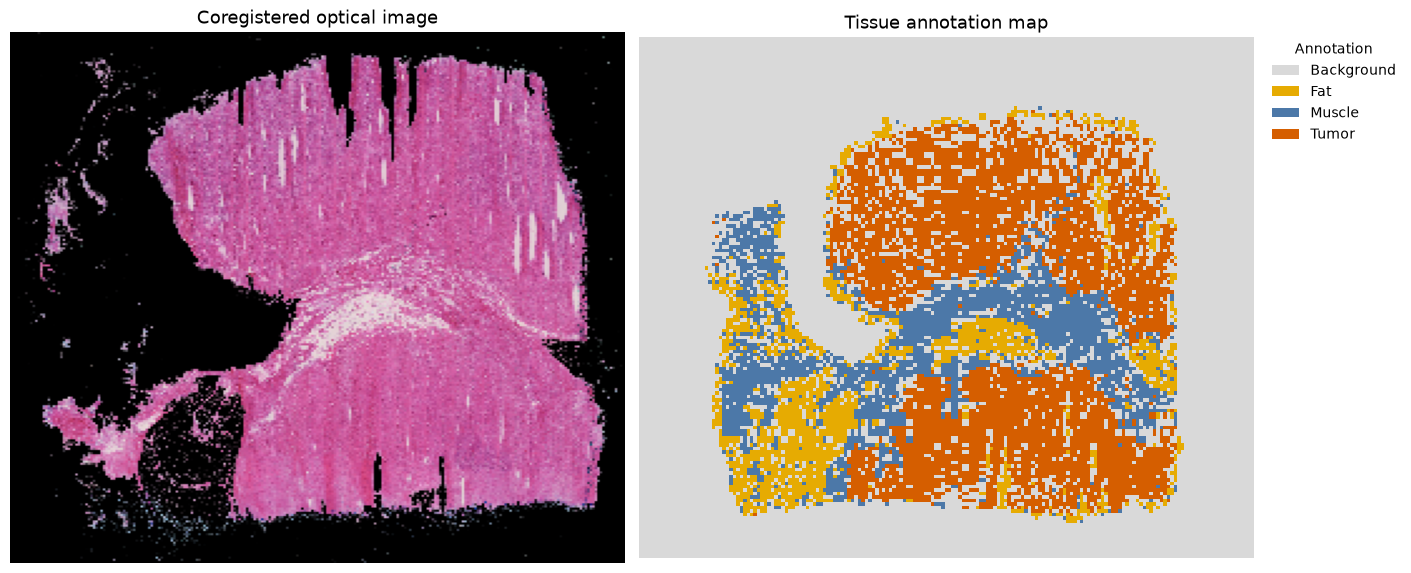

In [4]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

optical_img = mpimg.imread('optical_coreg.png')
# ------------------------------------------------------------------
# Reconstruct annotation image from data.
# ------------------------------------------------------------------
xy = tmp_train["Sample"].str.extract(r"pixel_(\d+)_(\d+)").astype(int)
x = xy[0].to_numpy()
y = xy[1].to_numpy()

class_names = ["Background", "Fat", "Muscle", "Tumor"]
class_to_id = {class_name: i for i, class_name in enumerate(class_names)}

class_id = tmp_train["Class"].map(class_to_id).to_numpy()

annotation_img = np.full((y.max(), x.max()), np.nan, dtype=float)
annotation_img[y - 1, x - 1] = class_id

# ------------------------------------------------------------------
# Categorical annotation palette.
# ------------------------------------------------------------------
class_colors = [
    "#D9D9D9",  # Background
    "#E6AB02",  # Fat
    "#4C78A8",  # Muscle
    "#D55E00",  # Tumor
]

class_cmap = ListedColormap(class_colors)
class_cmap.set_bad("#FFFFFF")

class_norm = BoundaryNorm(
    np.arange(-0.5, len(class_names) + 0.5, 1),
    ncolors=len(class_names)
)

# ------------------------------------------------------------------
# Plot optical image and annotation map side by side.
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7),
    constrained_layout=True
)

# Optical image
axes[0].imshow(optical_img, origin="upper")
axes[0].set_title("Coregistered optical image", fontsize=13)
axes[0].set_aspect(0.85)
axes[0].axis("off")

# Annotation map
axes[1].imshow(
    np.ma.masked_invalid(annotation_img),
    cmap=class_cmap,
    norm=class_norm,
    origin="upper",
    interpolation="none"
)

axes[1].set_title("Tissue annotation map", fontsize=13)
axes[1].set_aspect("equal")
axes[1].axis("off")

legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=class_name)
    for class_name, color in zip(class_names, class_colors)
]

axes[1].legend(
    handles=legend_handles,
    title="Annotation",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=False
)

plt.show()

## This is a breast cancer tissue biopsy from a real patient. As inferred from the correponding histopathology data (H&E-stained optical image), there are 3 distinct regions here: red = tumour, yellow=fat, blue= muscle. Let's sample some data in each region and do some analyses.

## First, let's remove all background and randomly sample 200 pixels from each region as the training data:

In [5]:
tmp_train_sampled = (
    tmp_train[tmp_train["Class"].isin(["Tumor", "Fat", "Muscle"])]
    .groupby("Class", group_keys=False)
    .sample(n=200, random_state=42)
)
Data_sampled = tmp_train_sampled.drop(columns=["Class",'Sample'])
Label_sampled = tmp_train_sampled["Class"]

tmp_train_sampled

,Sample,Class,102.058,102.063,102.065,107.038,107.04,107.045,108.023,108.025,...,1161.739,1165.751,1171.61,1172.612,1173.612,1175.641,1189.658,1190.665,1194.579,1199.563
18569,pixel_124_120,Fat,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22146,pixel_148_97,Fat,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,203.0,172.0,0.0,56.0,0.0,0.0,0.0,0.0
14190,pixel_95_91,Fat,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,307.0,71.0,0.0,0.0,0.0,0.0,0.0,0.0
8810,pixel_59_111,Fat,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,221.0,89.0,0.0,0.0,55.0,0.0,0.0,0.0
5363,pixel_36_114,Fat,0.0,0.0,0.0,101.0,101.0,0.0,0.0,0.0,...,0.0,0.0,128.0,75.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12670,pixel_85_71,Tumor,0.0,86.0,0.0,0.0,54.0,0.0,0.0,0.0,...,0.0,0.0,118.0,0.0,99.0,0.0,92.0,0.0,0.0,77.0
12582,pixel_84_133,Tumor,0.0,0.0,0.0,0.0,102.0,0.0,0.0,0.0,...,0.0,66.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21811,pixel_146_62,Tumor,0.0,118.0,118.0,170.0,170.0,107.0,132.0,132.0,...,50.0,0.0,0.0,40.0,61.0,0.0,41.0,94.0,0.0,0.0
20743,pixel_139_44,Tumor,0.0,90.0,0.0,0.0,150.0,0.0,0.0,0.0,...,0.0,69.0,220.0,102.0,0.0,0.0,107.0,102.0,0.0,0.0


## Let's start wih some Univariate analyses, first **ANOVA** between the 3 classes

#### Normalization

In [9]:
Data_n = Data_train / (Data_train.sum(axis=1).values[:,None] + 1e-12) * 1e6
Data_log = np.log1p(Data_n)

print(Data_train.shape, Data_log.shape)

(600, 2023) (600, 2023)


## Step 1) for each m/z feature, we look at the 200 data points in each class and compare their means, computing their test statistics and corresponding p-values

In [6]:
column = Label_sampled
labelnames = list(np.unique(column))
X = Data_sampled if hasattr(Data_sampled,"iloc") else pd.DataFrame(Data_sampled)

p_vals_ANOVA = np.zeros(len(mz))
for i in range(len(mz)):
    groups = [X[column==c].iloc[:,i] for c in labelnames]
    if len(set([np.round(g.mean(),4) for g in groups])) == 1:
        p_vals_ANOVA[i] = 1
    else:
        p_vals_ANOVA[i] = stats.f_oneway(*groups).pvalue

## Step 2) we need to FDR correction on the computed p-values. (The corrected values are also called **q-values**).

In [36]:
rejected, q_vals_ANOVA = statsmodels.stats.multitest.fdrcorrection(p_vals_ANOVA, alpha=0.05, method="indep")
q_vals_ANOVA = np.where(q_vals_ANOVA==0, 1e-15, q_vals_ANOVA)

## Step 3) we retain all those features that have a p-value < 0.05, this is essentially a univariate feature selection threshold. Let's look at the top 20 features.

In [37]:
ANOVA_result = pd.DataFrame({
    "m/z": mz,
    "p_value": p_vals_ANOVA,
    "q_value": q_vals_ANOVA,
    "-log10q": -np.log10(q_vals_ANOVA),
    "significant": q_vals_ANOVA <= 0.05
})

ANOVA_features = ANOVA_result[ANOVA_result["significant"]].sort_values("q_value")
ANOVA_features.head(20)

,m/z,p_value,q_value,-log10q,significant
1362,717.568,3.596536e-114,7.275793e-111,110.138120,True
1075,573.518,6.059847e-113,6.129535e-110,109.212572,True
1071,572.515,2.172948e-112,1.465292e-109,108.834076,True
1351,714.550,3.755497e-111,1.899343e-108,107.721397,True
200,174.050,4.663372e-110,1.886800e-107,106.724274,True
1661,864.714,1.681744e-108,5.670279e-106,105.246396,True
1358,716.565,8.077846e-107,2.334497e-104,103.631807,True
1399,734.576,2.372447e-106,5.999325e-104,103.221898,True
1426,742.582,2.337762e-105,5.254769e-103,102.279446,True
1430,743.586,4.047762e-104,8.188622e-102,101.086789,True


## We can also visualise by **box plots**:

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 47.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


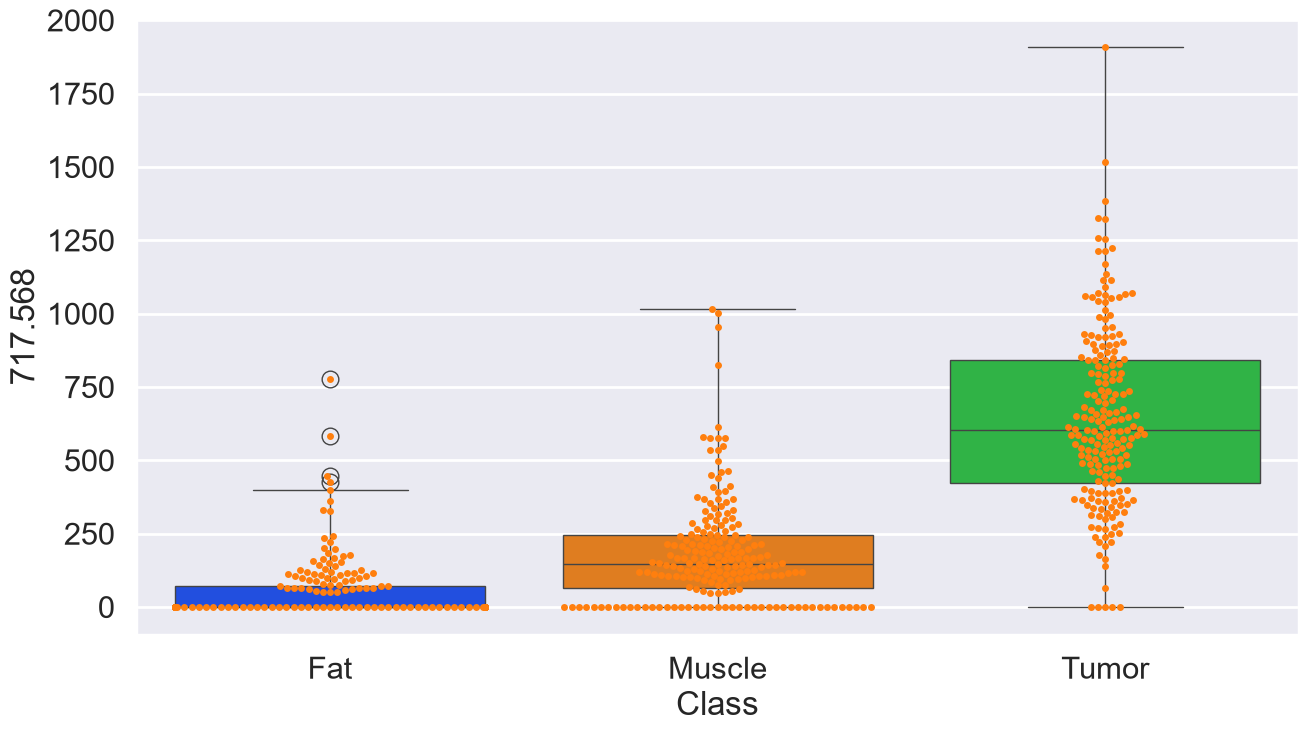

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 53.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 52.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


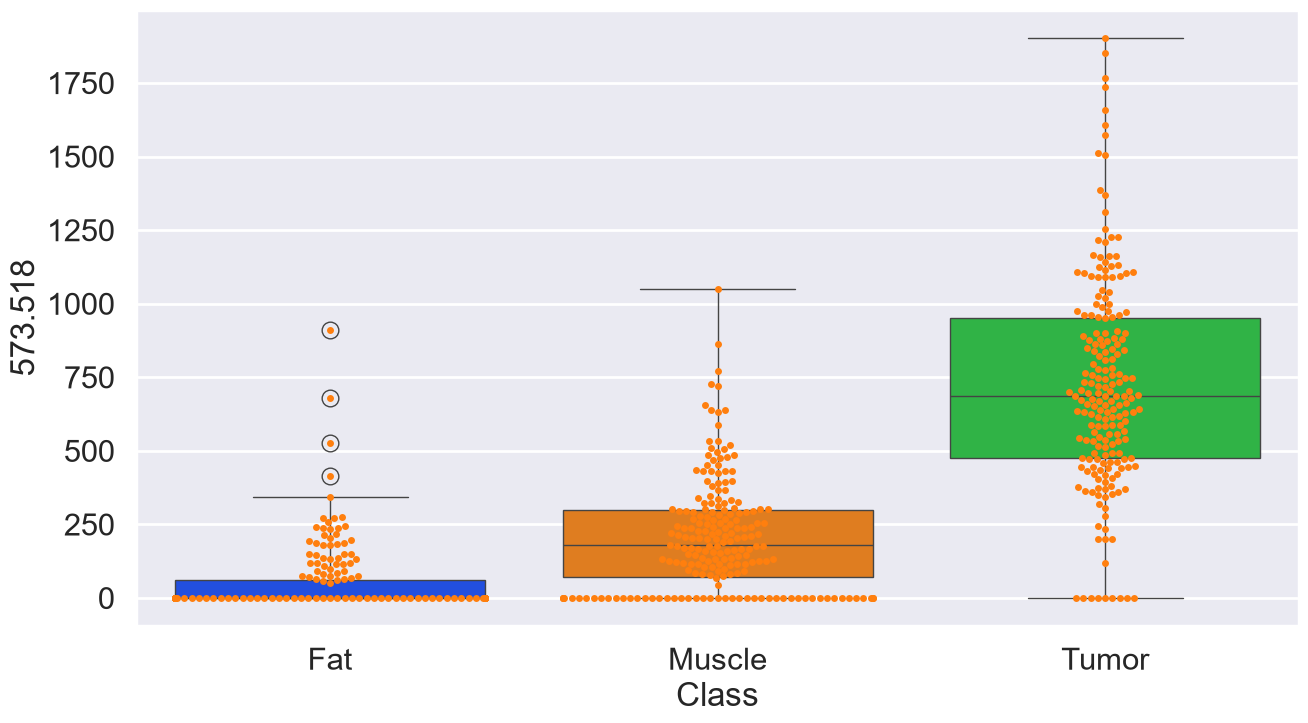

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 28.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 27.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


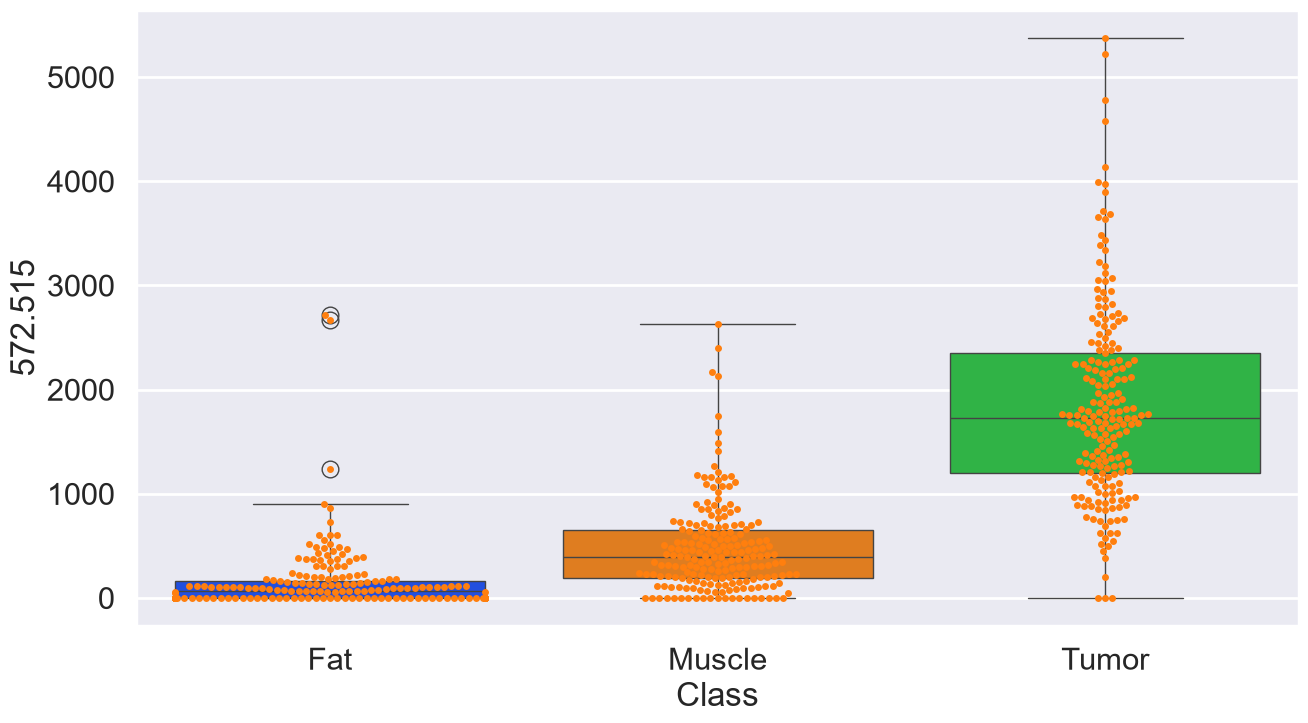

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 42.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 41.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


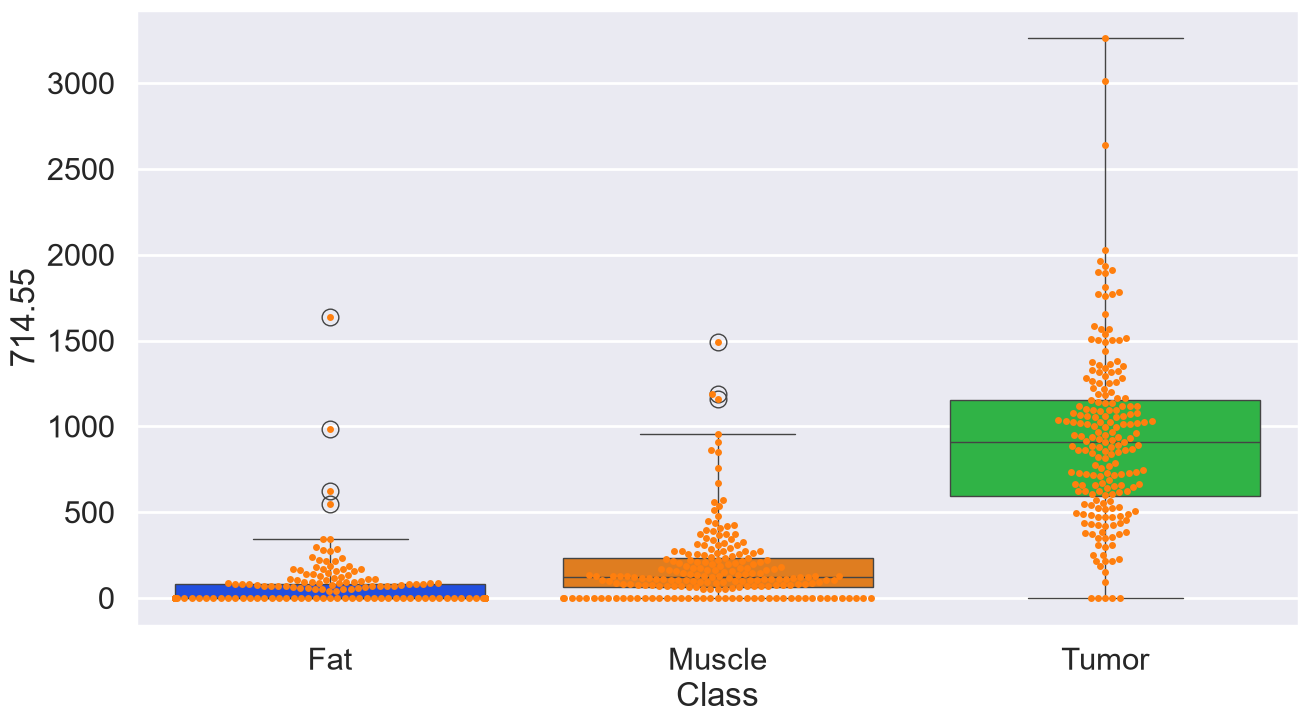

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 23.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 22.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


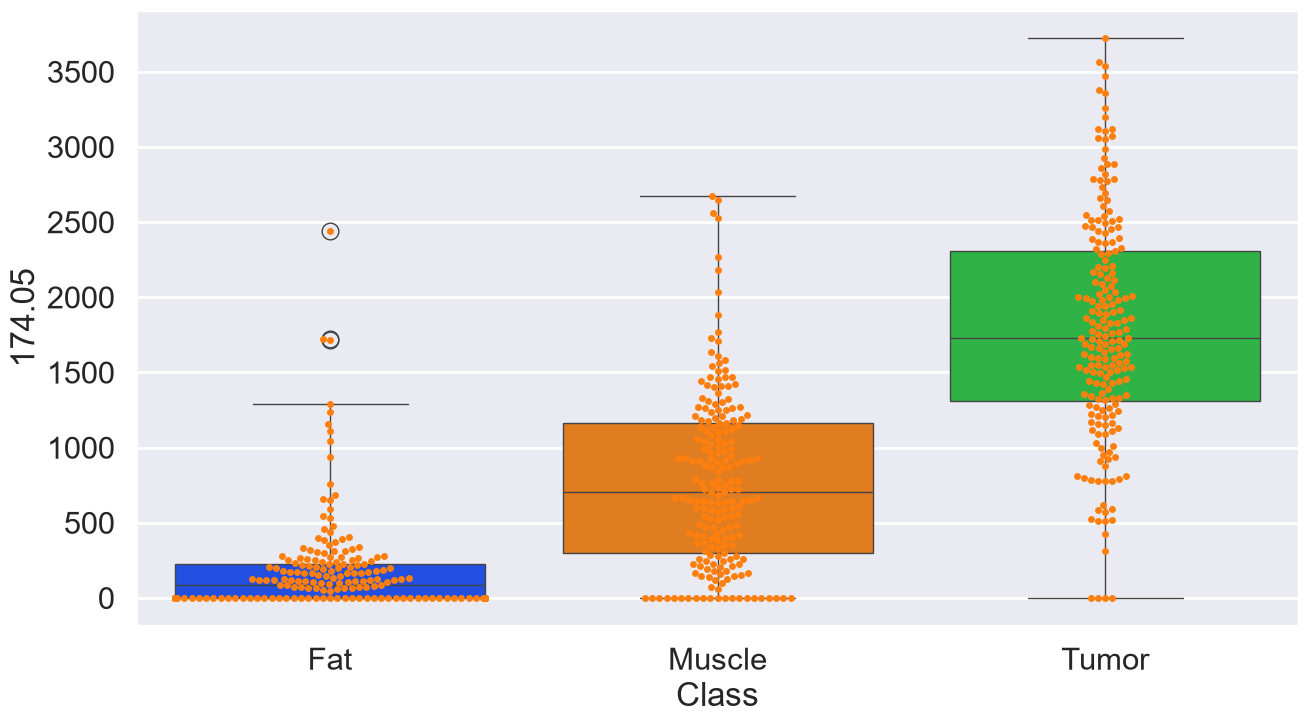

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 44.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 39.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 43.5% of the points cannot be placed; you may want to decre

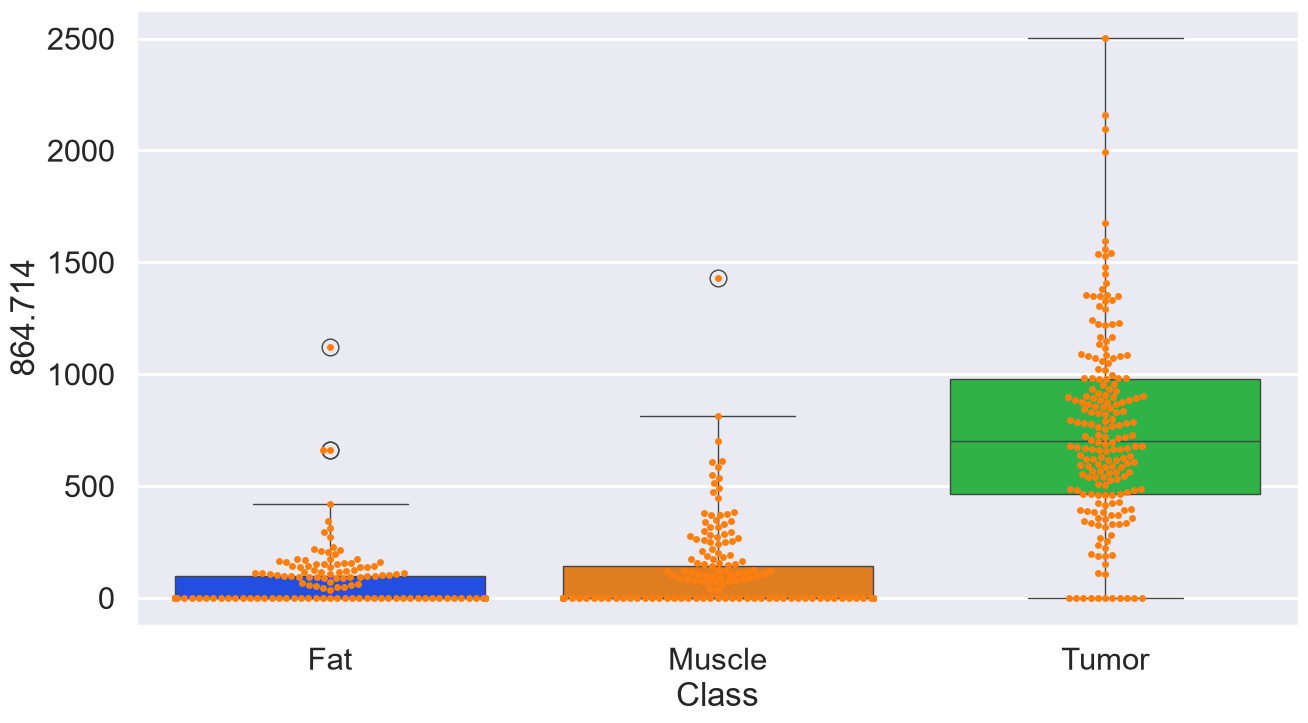

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 24.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


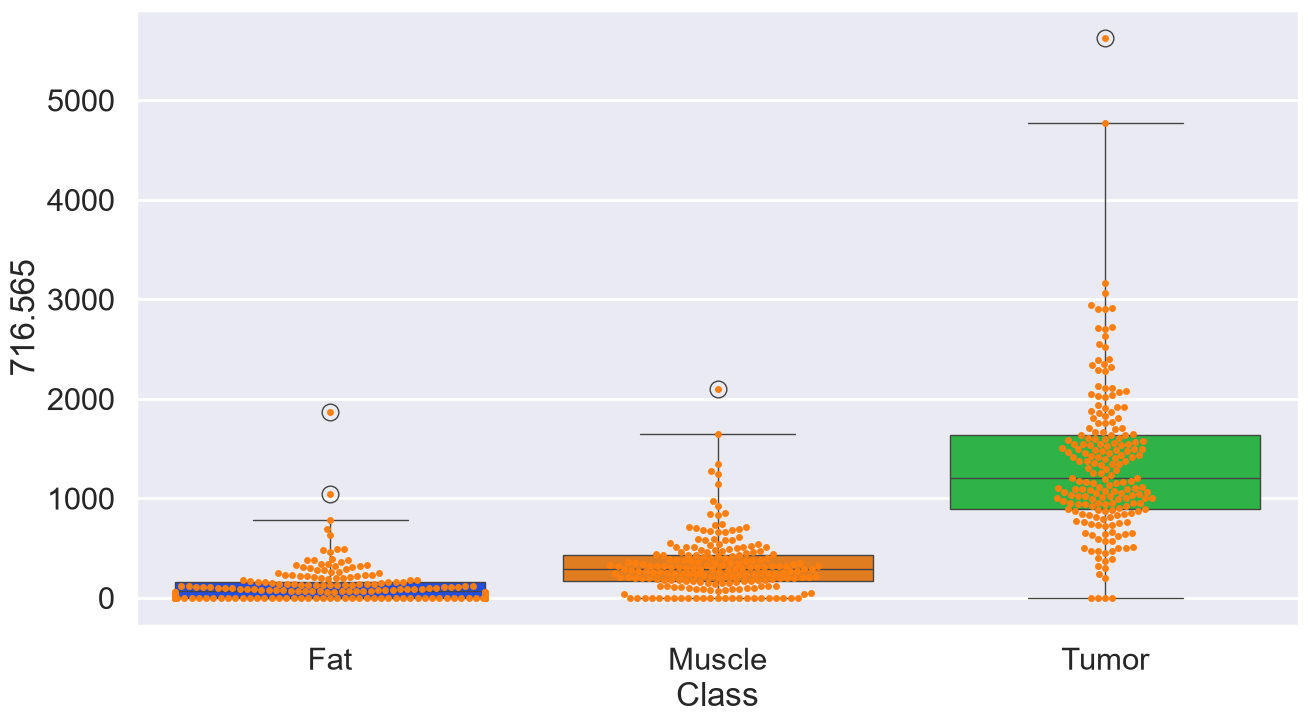

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 51.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrea

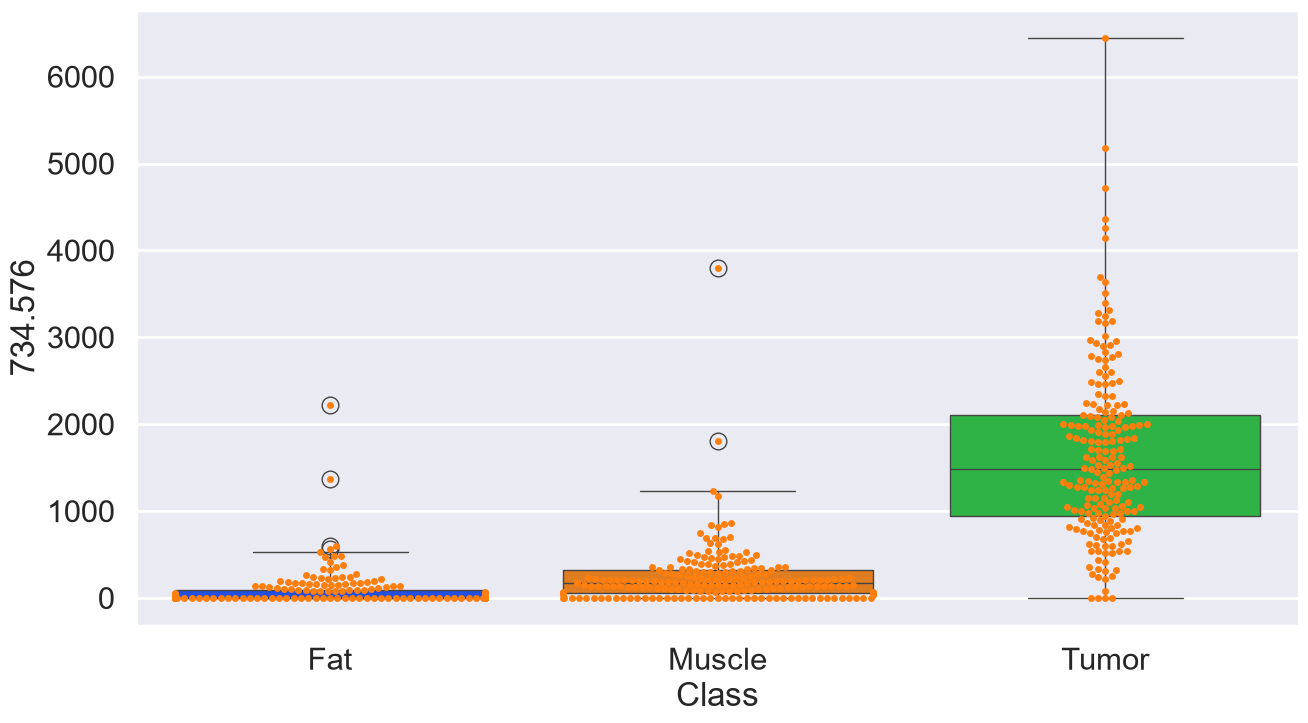

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 19.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


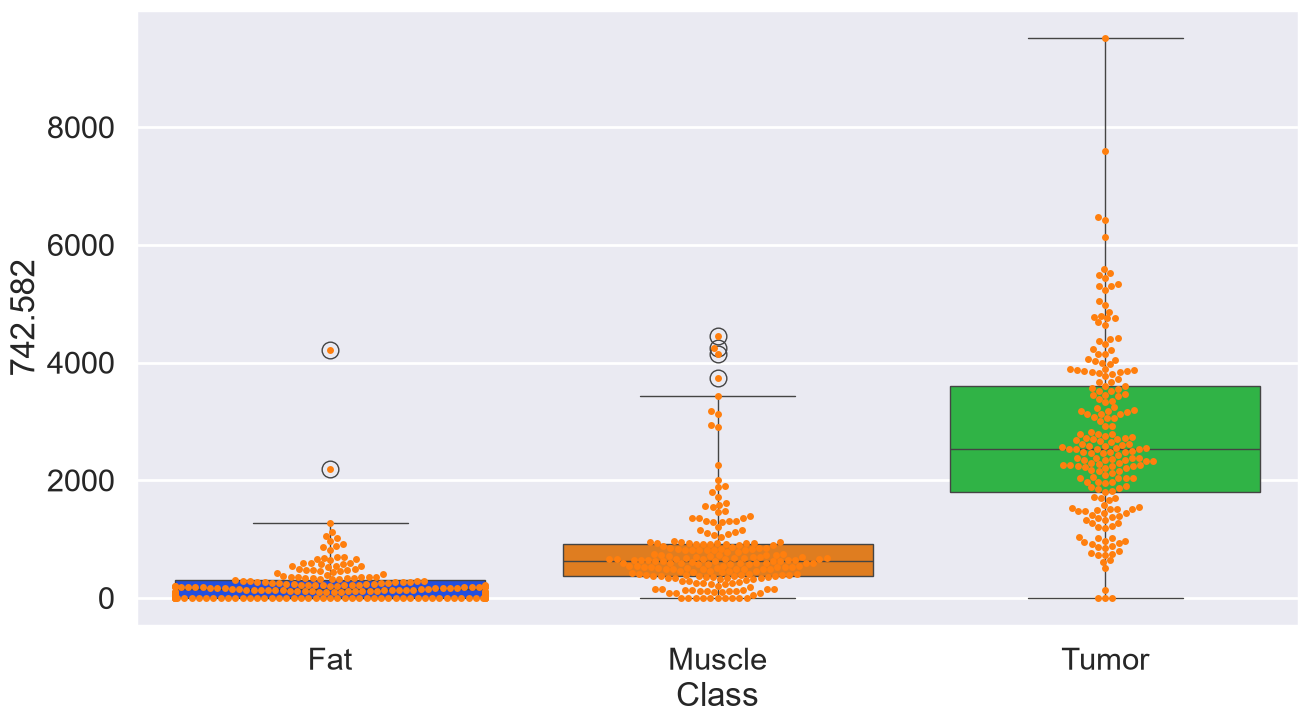

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 33.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


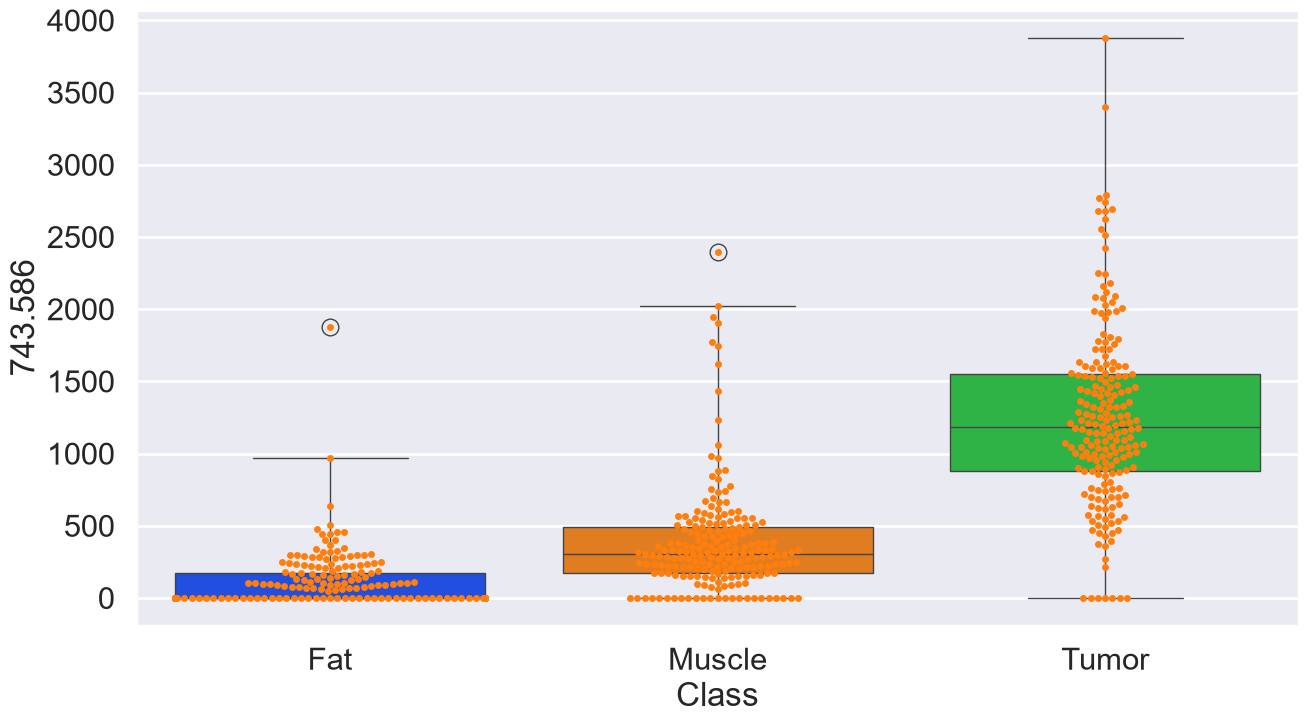

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 22.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


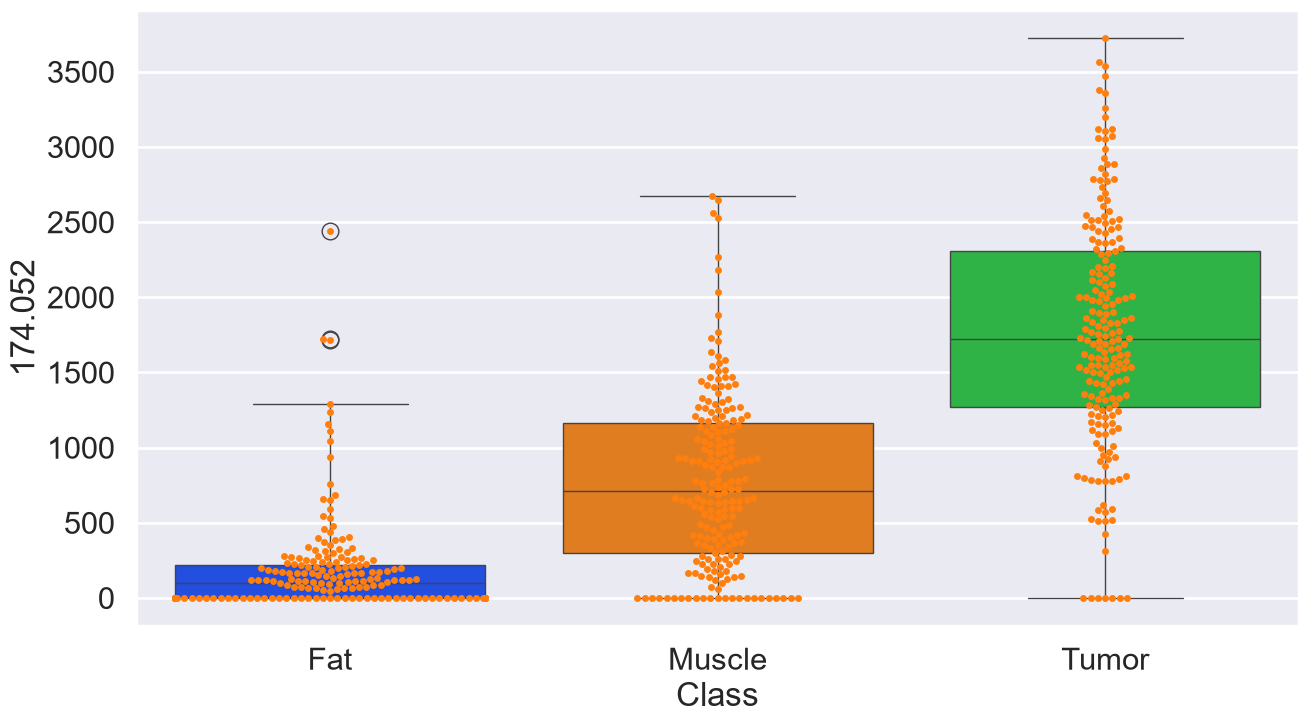

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 56.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 33.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 55.5% of the points cannot be placed; you may want to decre

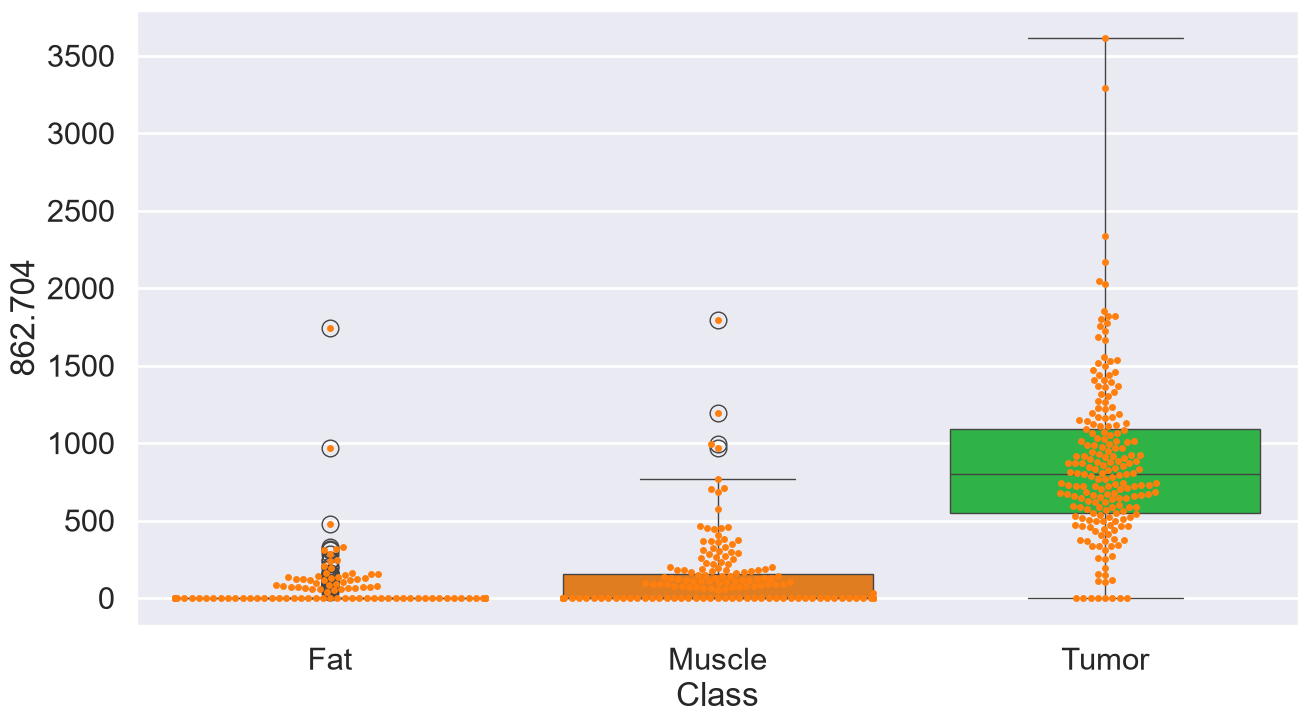

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 69.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 35.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 68.0% of the points cannot be placed; you may want to decre

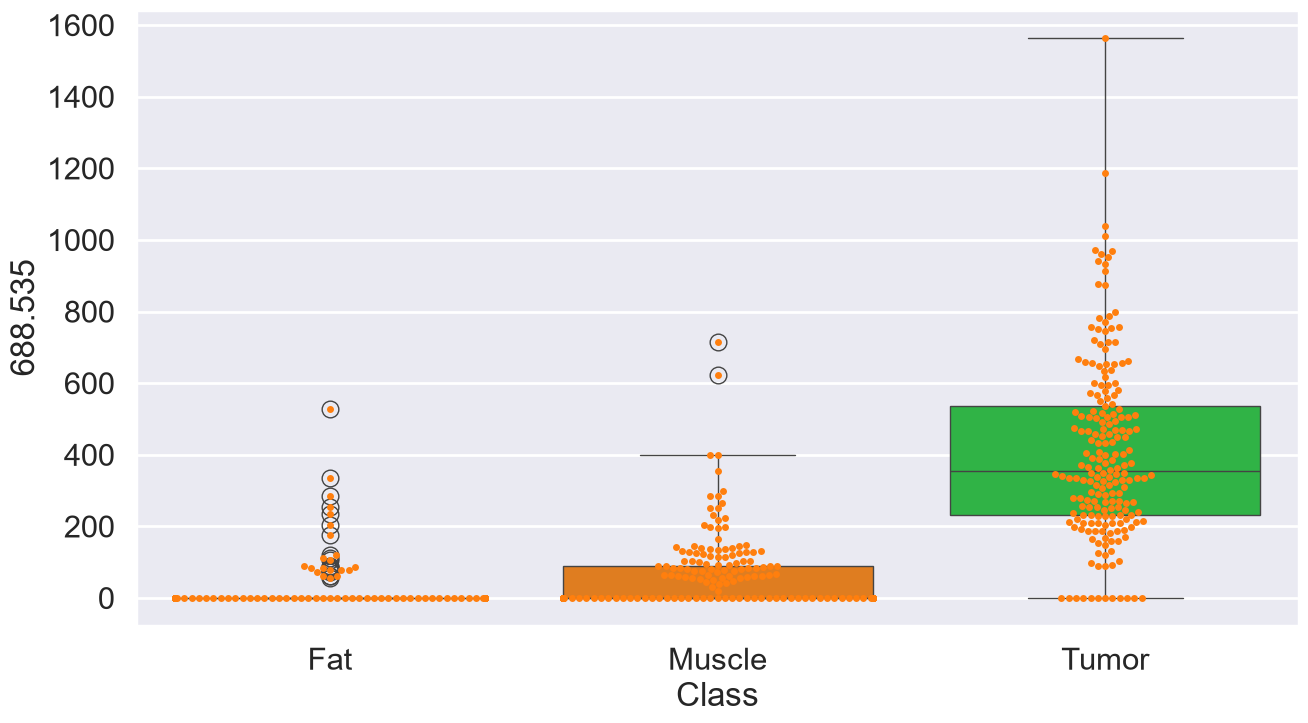

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 63.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 52.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 62.0% of the points cannot be placed; you may want to decre

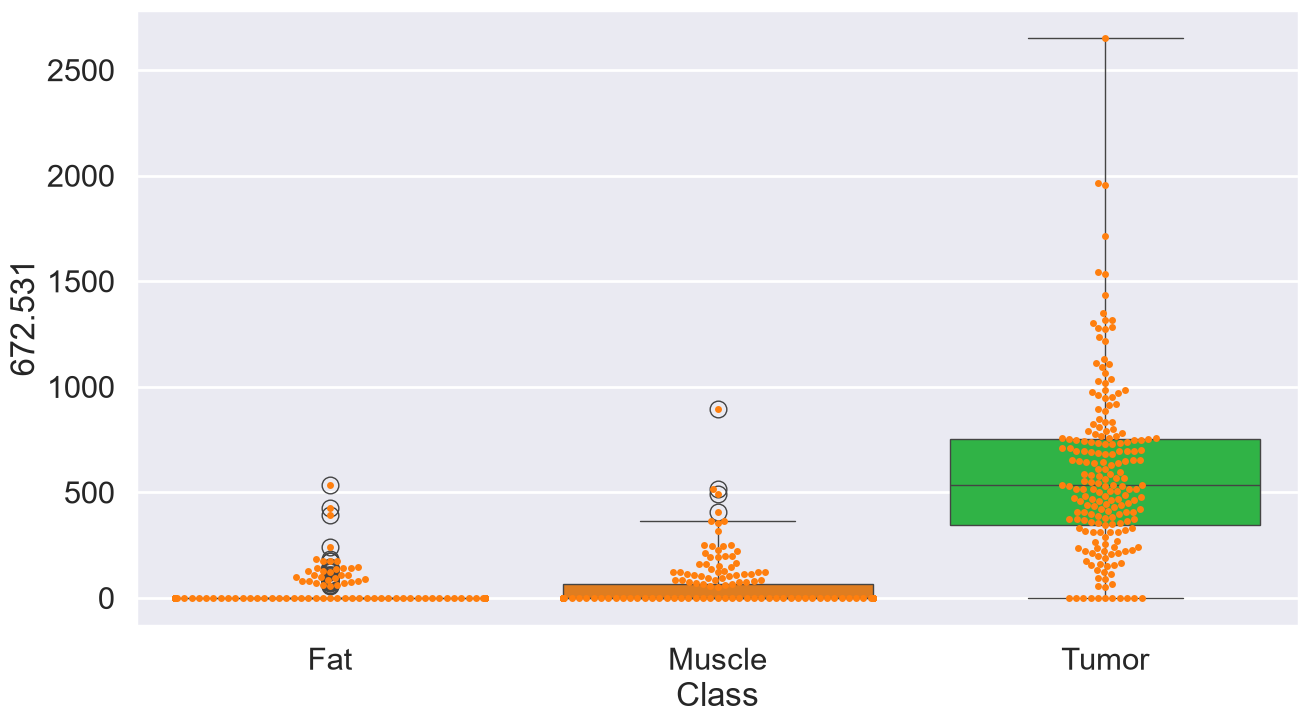

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 47.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


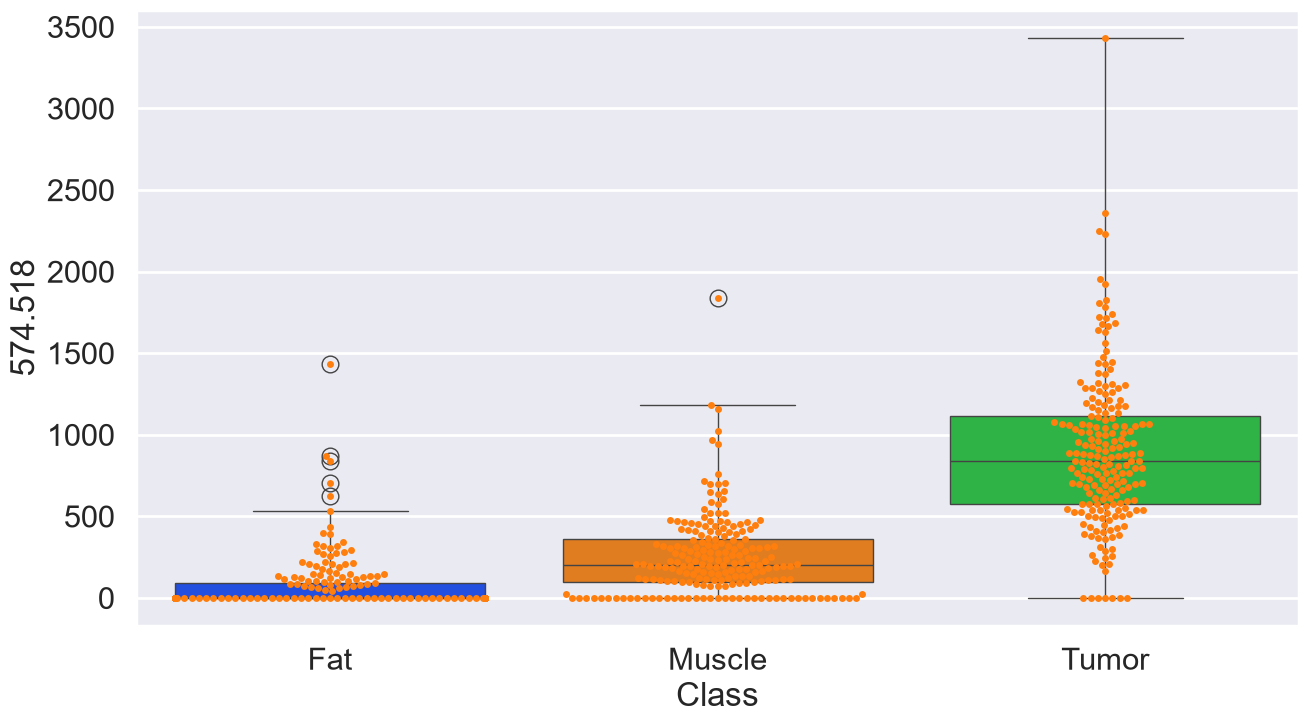

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 70.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 69.0% of the points cannot be placed; you may want to decre

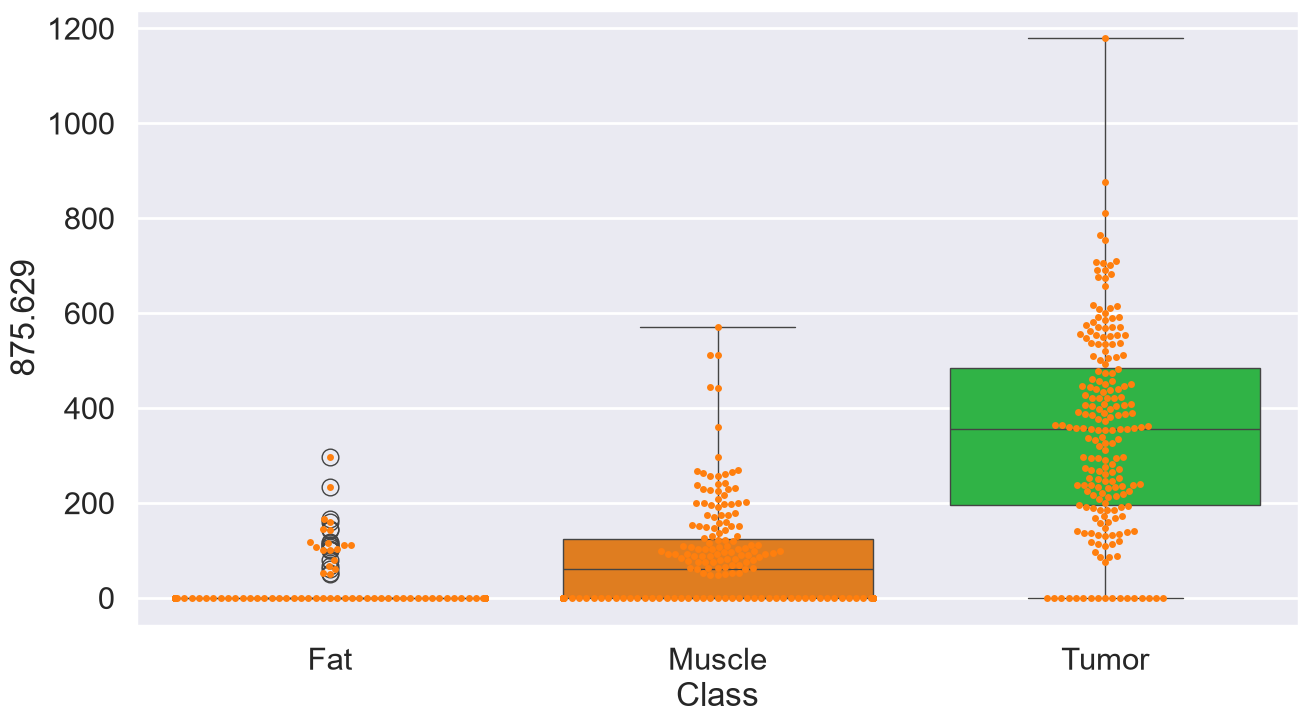

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 58.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 57.5% of the points cannot be placed; you may want to decre

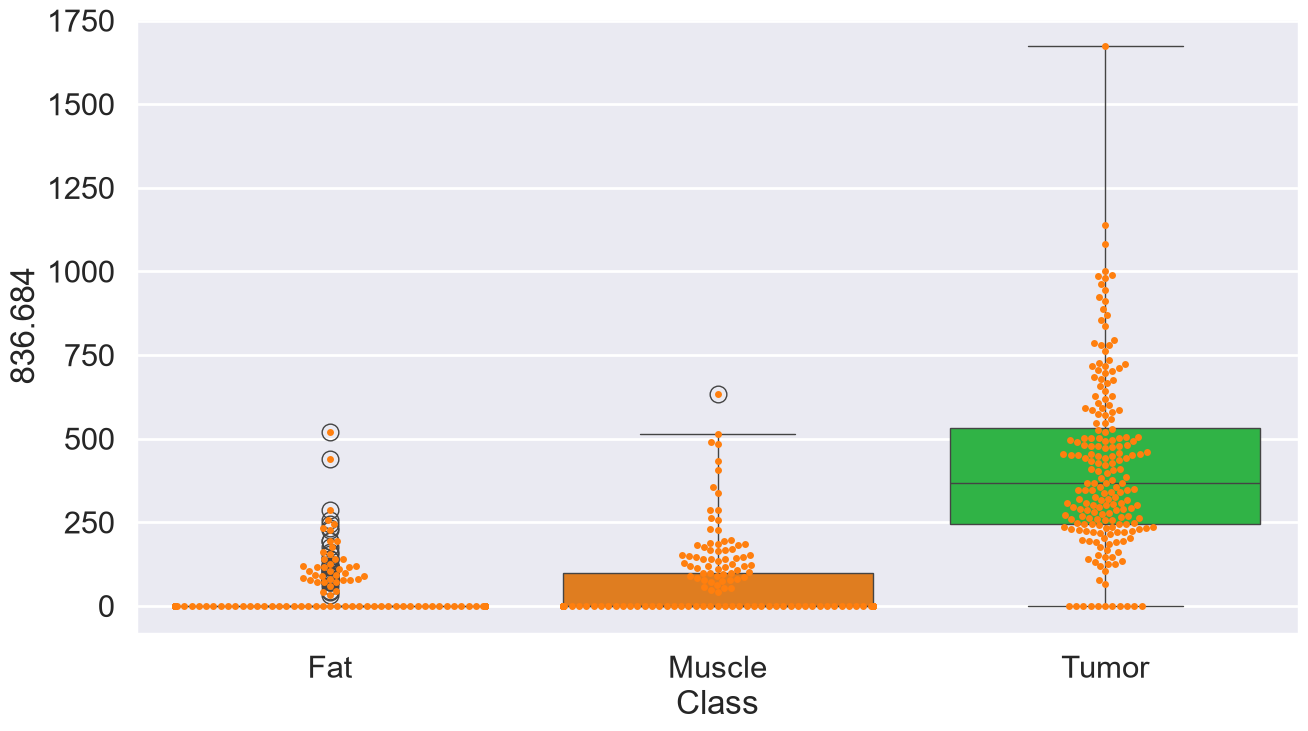

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 61.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 60.5% of the points cannot be placed; you may want to decre

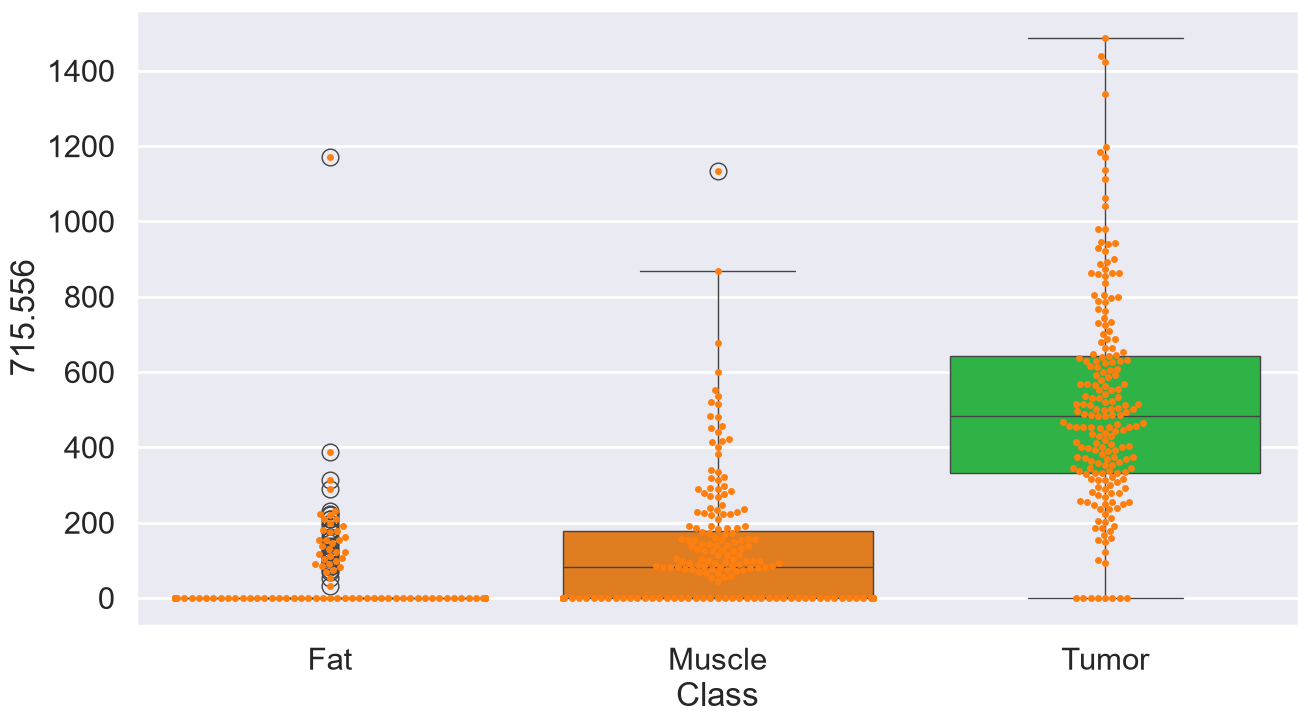

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 68.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 67.0% of the points cannot be placed; you may want to decre

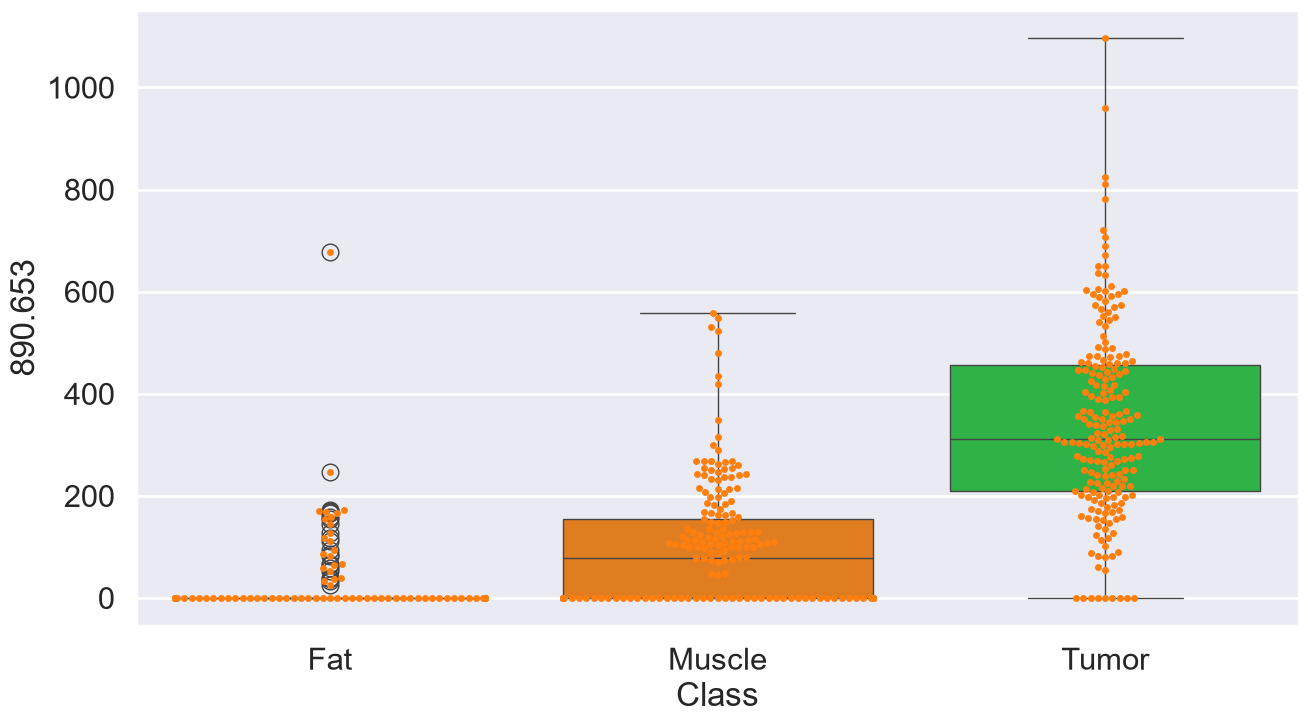

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 73.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 67.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 72.5% of the points cannot be placed; you may want to decre

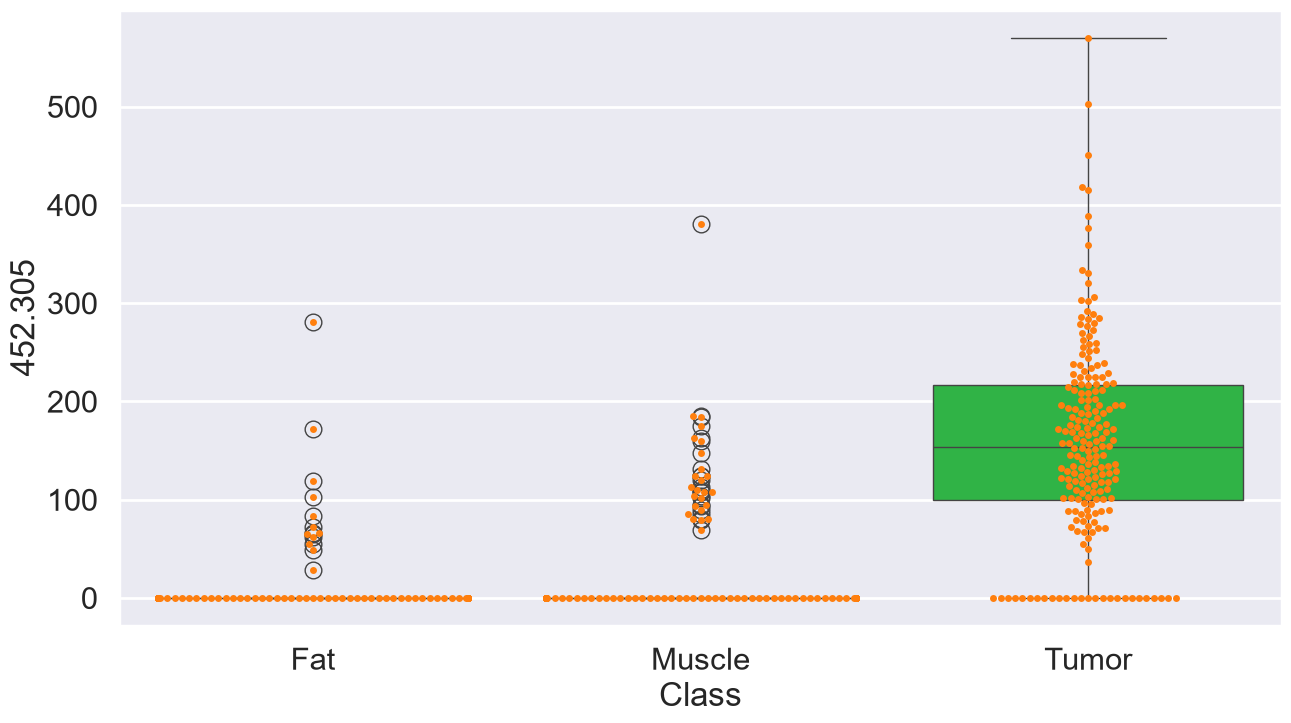

In [42]:
box_plot(ANOVA_features.head(20)['m/z'], mz, tmp_train_sampled,'Class', save=False)

## By inspection, the top 20 features are mostly lipid species and seem upregulated in cancer, thus fitting in with biological expectation.

## Let's look at these on a more global scale, using a **volcano plot**:

## First, we will need to calculate fold-changes. Volcano plots are specifically for binary comparison, so let's choose Tumour vs Fat.

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\2148740472.py:8: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  mean1 = g1.mean(0).values
C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_34636\2148740472.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  mean2 = g2.mean(0).values


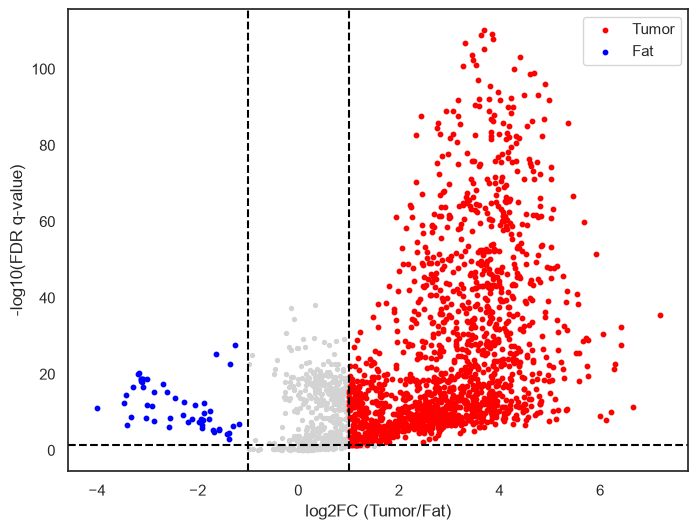

In [48]:
# Volcano plot: choose two classes
class1, class2 = "Fat", "Tumor"
g1 = X[column==class1]
g2 = X[column==class2]

correct_p_pair = np.where(q_vals_ANOVA==0, 1e-15, q_vals_ANOVA)

mean1 = g1.mean(0).values
mean2 = g2.mean(0).values
mean1 = np.where(mean1==0, 1, mean1)
mean2 = np.where(mean2==0, 1, mean2)
log2fc = np.log2(mean2/mean1)

volcano_data = pd.DataFrame({"m.z":[str(m) for m in mz], "p.value":correct_p_pair.astype(float), "t.score":log2fc})

# Plot volcano

fc_threshold = 1
p_threshold = 0.05

up = (volcano_data["p.value"] <= p_threshold) & (volcano_data["t.score"] >= fc_threshold)
down = (volcano_data["p.value"] <= p_threshold) & (volcano_data["t.score"] <= -fc_threshold)
condition = up | down

sns.set_context("notebook")
sns.set_style("white")
plt.figure(figsize=(8,6))
plt.scatter(volcano_data["t.score"], -np.log10(volcano_data["p.value"]), s=8, c="lightgray")
plt.scatter(volcano_data.loc[up,"t.score"], -np.log10(volcano_data.loc[up,"p.value"]), s=10, c="red", label=class2)
plt.scatter(volcano_data.loc[down,"t.score"], -np.log10(volcano_data.loc[down,"p.value"]), s=10, c="blue", label=class1)
plt.axhline(-np.log10(p_threshold), color="k", ls="--")
plt.axvline(fc_threshold, color="k", ls="--")
plt.axvline(-fc_threshold, color="k", ls="--")
plt.xlabel(f"log2FC ({class2}/{class1})")
plt.ylabel("-log10(FDR q-value)")
plt.legend()
plt.show()

vol_features = pd.DataFrame(mz[condition], columns=["vol_features"])

## This further confirms our earlier impression that, with a standard threshold of p-val<0.05 and fold change > +-1, most significant species are upregulated in tumour.

## Now let's try a non-parametric test to see if anything changes, namely the **Kruskal-Wallis test** that we learnt about:

In [7]:
p_vals_KW = np.zeros(len(mz))
for i in range(len(mz)):
    groups = [X[column==c].iloc[:,i] for c in labelnames]
    if len(set([np.round(g.mean(),4) for g in groups])) == 1:
        p_vals_KW[i] = 1
    else:
        p_vals_KW[i] = stats.kruskal(*groups).pvalue

rejected, correct_p = statsmodels.stats.multitest.fdrcorrection(p_vals_KW, alpha=0.05, method="indep")
correct_p = np.where(correct_p==0, 1e-15, correct_p)

KW_result = pd.DataFrame({"m/z":mz, "p_value":p_vals_KW, "q_value":correct_p, "-log10q":-np.log10(correct_p)})
KW_features = KW_result[KW_result["q_value"] <= 0.05].sort_values("q_value")
KW_features.head(20)

,m/z,p_value,q_value,-log10q
1399,734.576,1.289975e-86,2.609619e-83,82.583423
1071,572.515,3.412990e-85,3.452239e-82,81.461899
1228,672.531,1.602679e-84,1.080740e-81,80.966279
1426,742.582,7.066481e-84,2.859098e-81,80.543771
1315,700.567,6.681122e-84,2.859098e-81,80.543771
1358,716.565,3.087657e-83,1.041055e-80,79.982526
1362,717.568,2.974593e-82,7.289288e-80,79.137315
1288,688.535,3.242886e-82,7.289288e-80,79.137315
1321,702.577,2.677180e-82,7.289288e-80,79.137315
1351,714.550,7.412031e-82,1.499454e-79,78.824067


C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_9948\3435239582.py:7: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  mean1 = g1.mean(0).values; mean2 = g2.mean(0).values


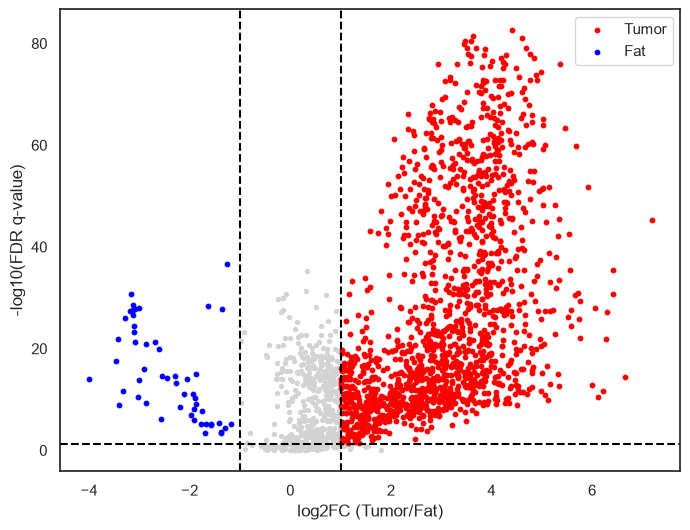

In [9]:
class1, class2 = "Fat", "Tumor"
g1 = X[column==class1]
g2 = X[column==class2]

correct_p_pair = np.where(correct_p==0, 1e-15, correct_p)

mean1 = g1.mean(0).values; mean2 = g2.mean(0).values
mean1 = np.where(mean1==0, 1, mean1); mean2 = np.where(mean2==0, 1, mean2)
log2fc = np.log2(mean2/mean1)

volcano_data = pd.DataFrame({"m/z":mz, "p_value":correct_p_pair, "log2FC":log2fc, "-log10q":-np.log10(correct_p_pair)})
# Plot volcano and select features

p_threshold = 0.05
fc_threshold = 1
up = (volcano_data["p_value"] <= p_threshold) & (volcano_data["log2FC"] >= fc_threshold)
down = (volcano_data["p_value"] <= p_threshold) & (volcano_data["log2FC"] <= -fc_threshold)
condition = up | down


sns.set_context("notebook")
sns.set_style("white")
plt.figure(figsize=(8,6))
plt.scatter(volcano_data["log2FC"], volcano_data["-log10q"], s=8, c="lightgray")
plt.scatter(volcano_data.loc[up,"log2FC"], volcano_data.loc[up,"-log10q"], s=10, c="red", label=class2)
plt.scatter(volcano_data.loc[down,"log2FC"], volcano_data.loc[down,"-log10q"], s=10, c="blue", label=class1)
plt.axhline(-np.log10(p_threshold), color="k", ls="--")
plt.axvline(fc_threshold, color="k", ls="--")
plt.axvline(-fc_threshold, color="k", ls="--")
plt.xlabel(f"log2FC ({class2}/{class1})")
plt.ylabel("-log10(FDR q-value)")
plt.legend()
plt.show()

vol_features = volcano_data[condition].sort_values("log2FC",ascending=False)

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 51.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 5.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrea

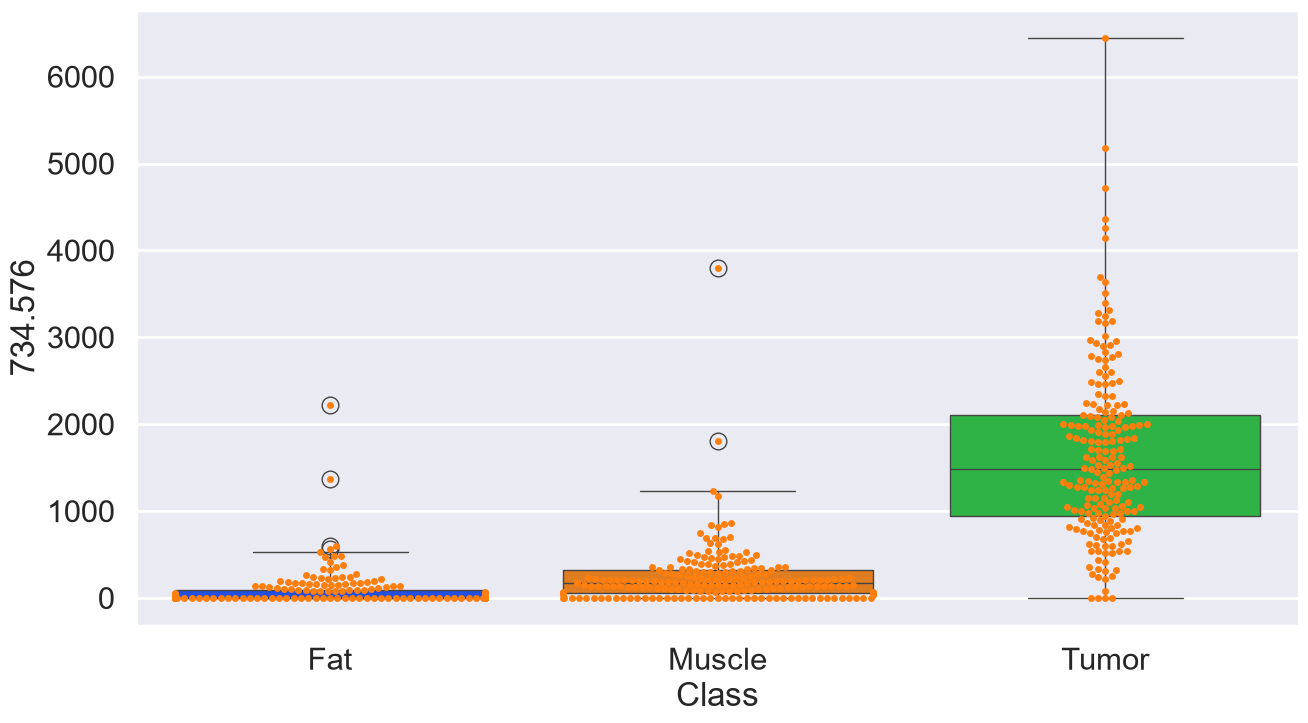

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 28.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 27.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


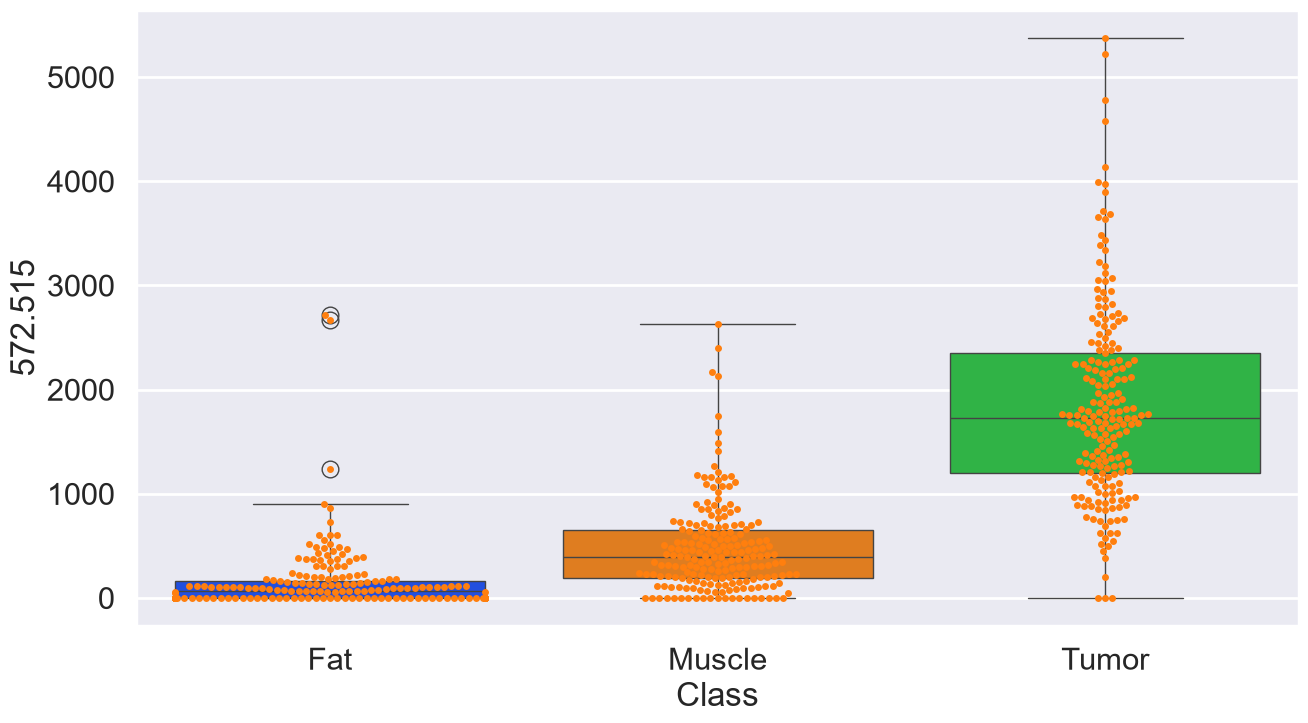

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 63.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 52.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 62.0% of the points cannot be placed; you may want to decre

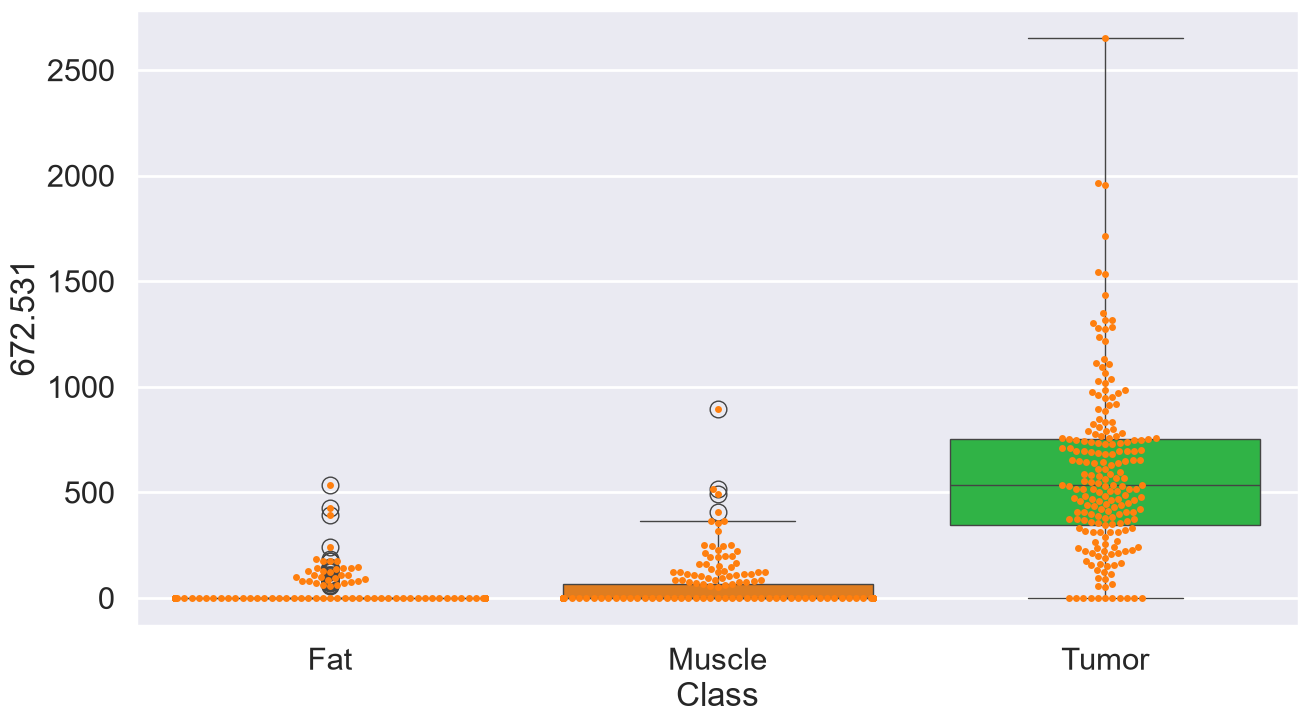

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 19.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


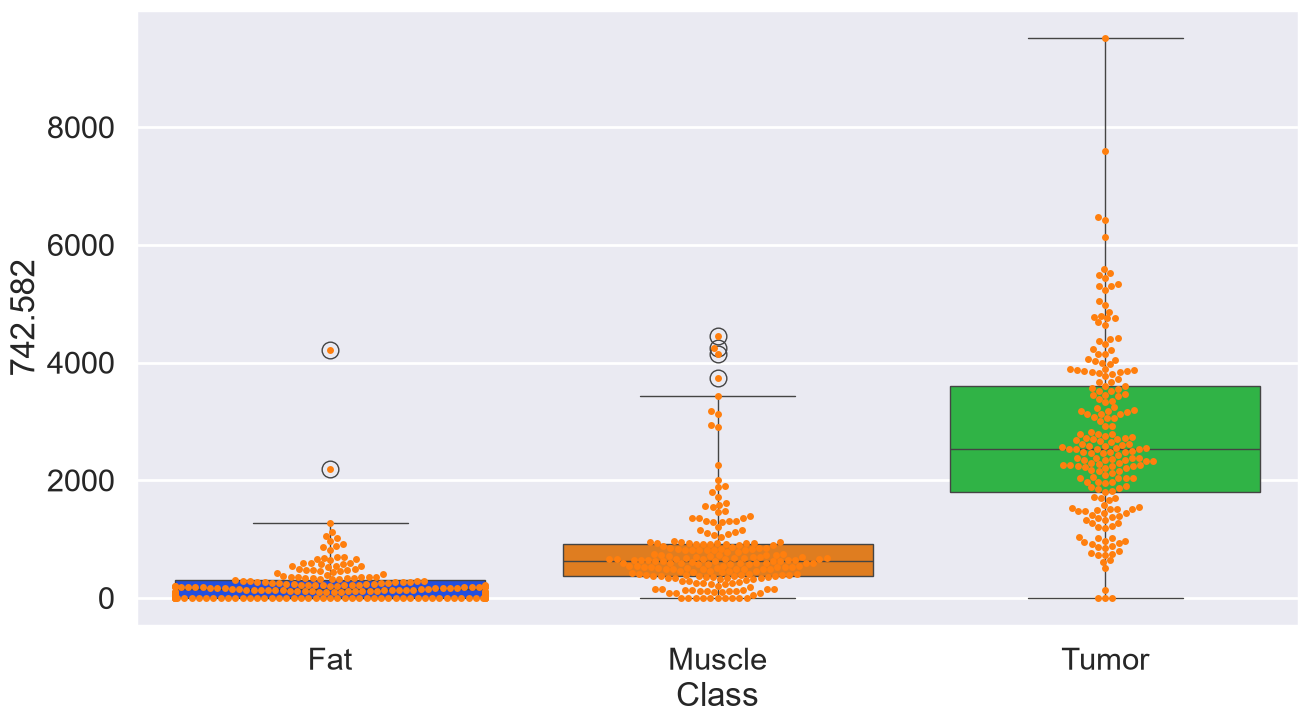

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 31.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


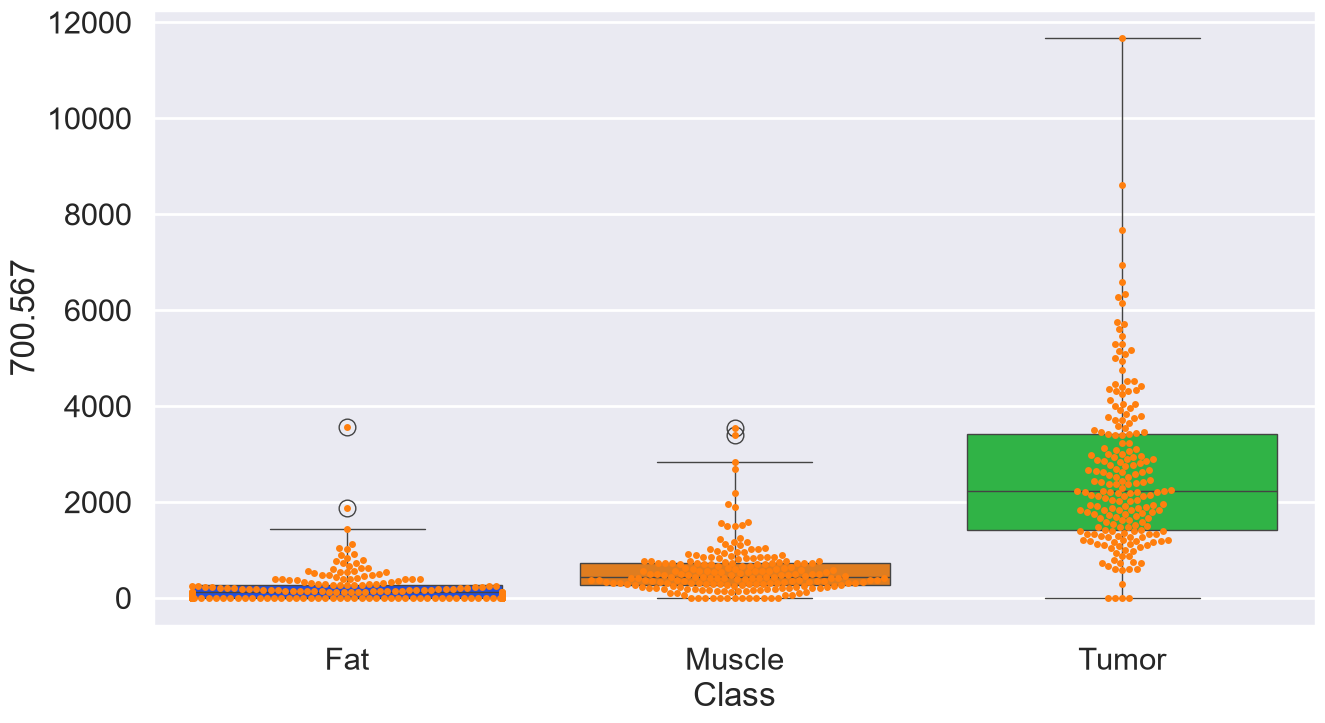

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 24.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


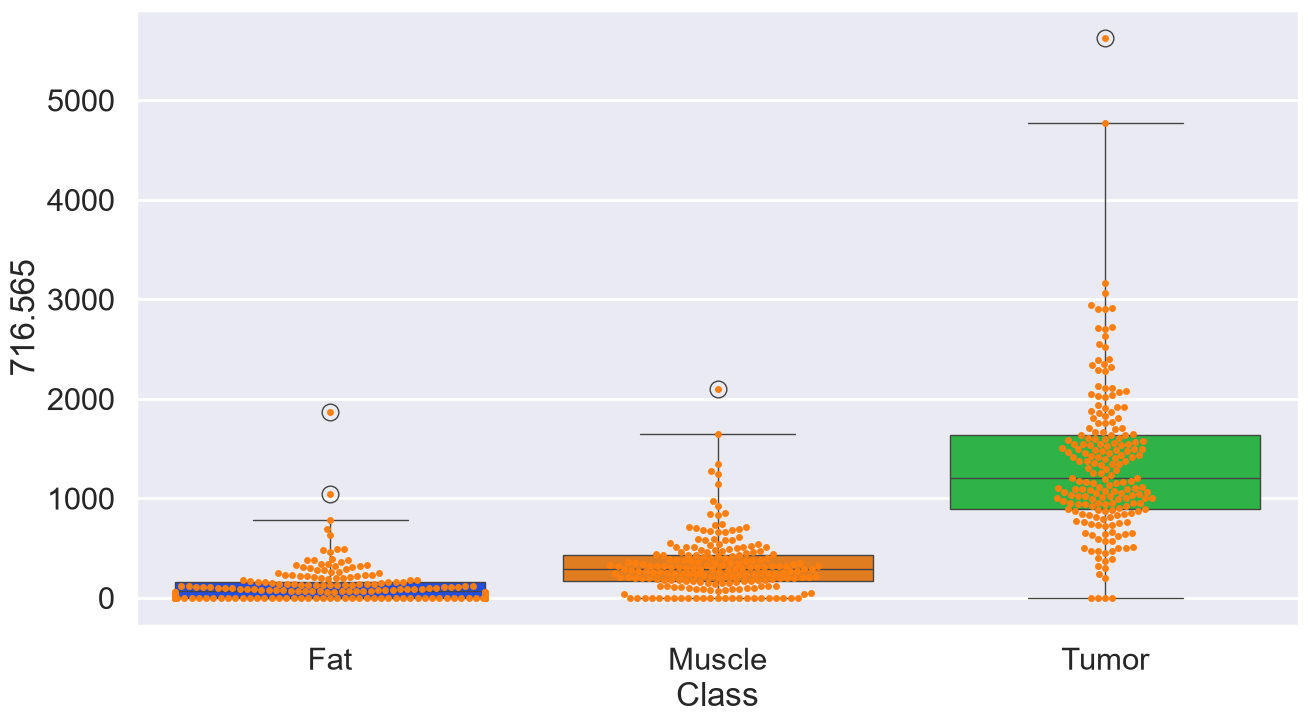

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 47.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


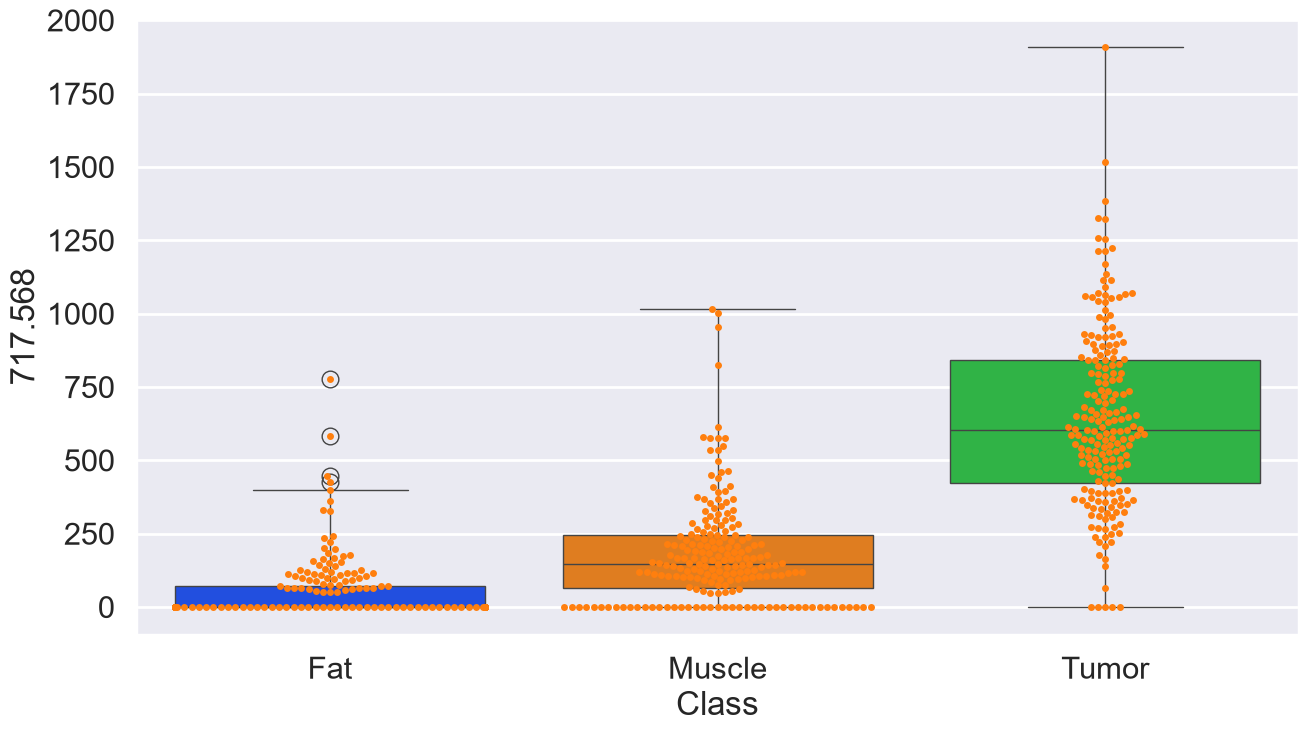

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 69.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 35.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 68.0% of the points cannot be placed; you may want to decre

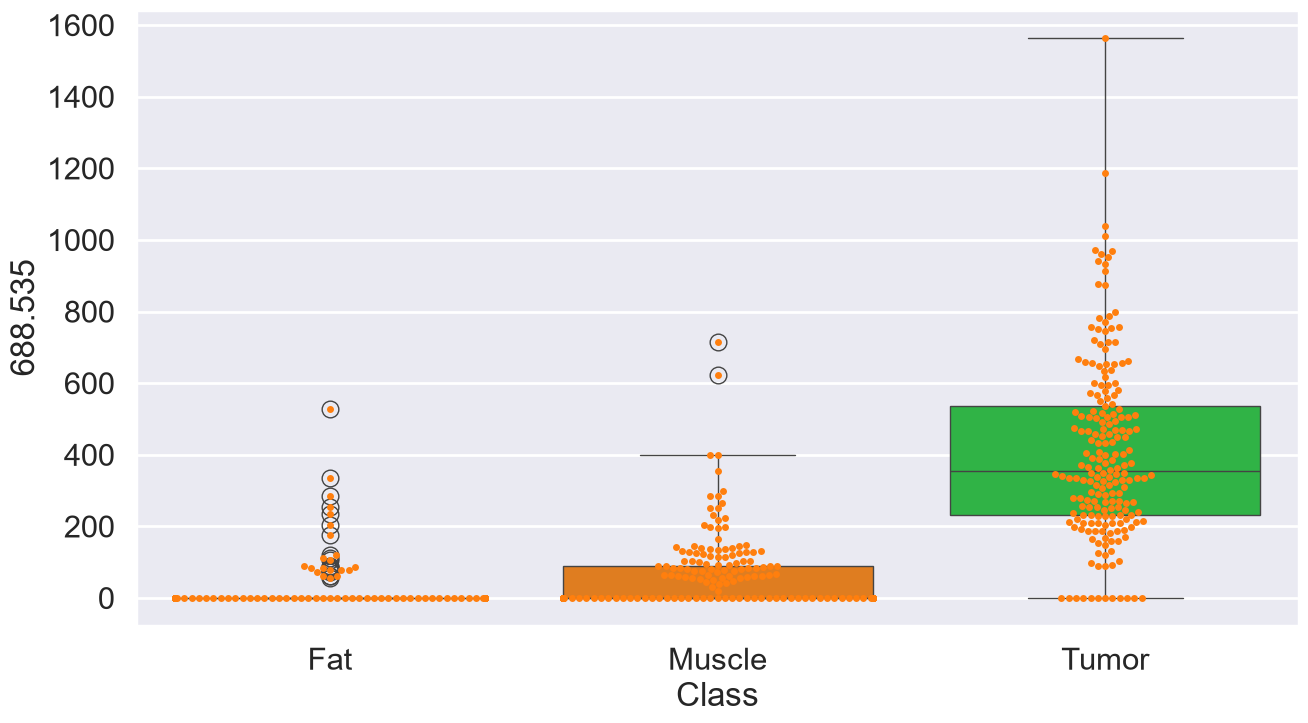

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 45.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 44.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


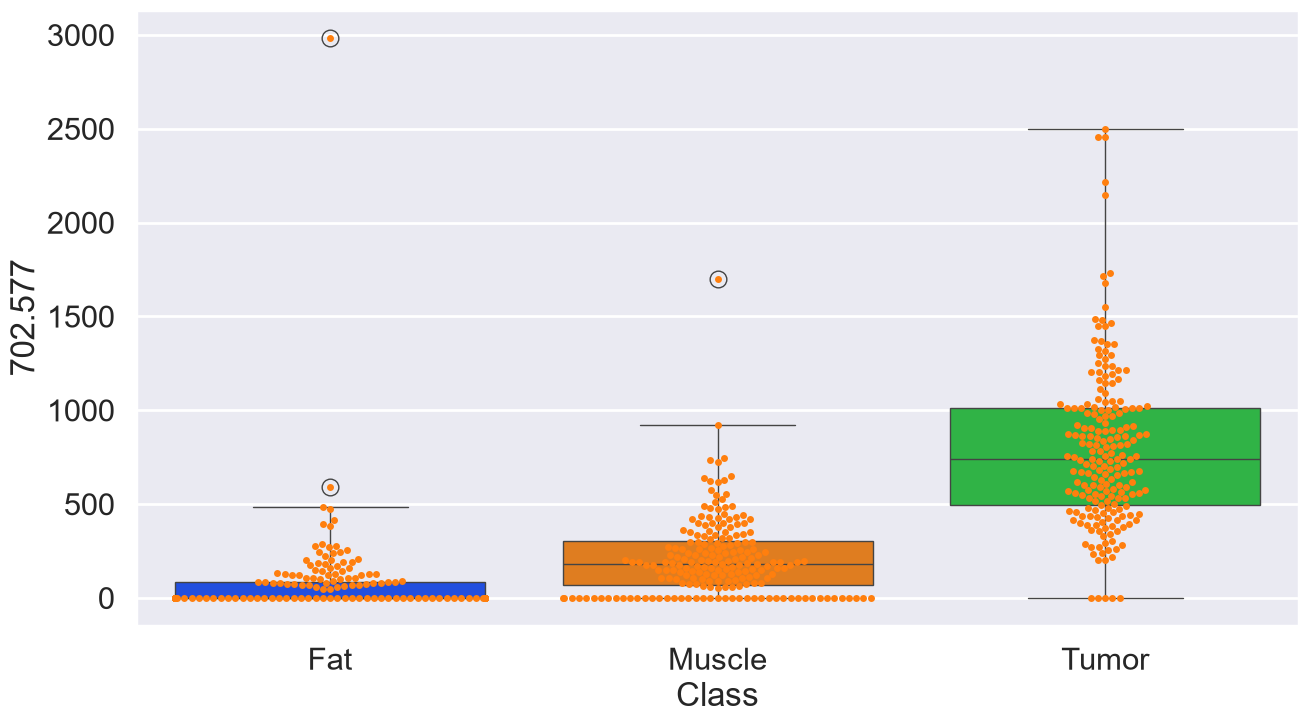

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 42.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 41.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


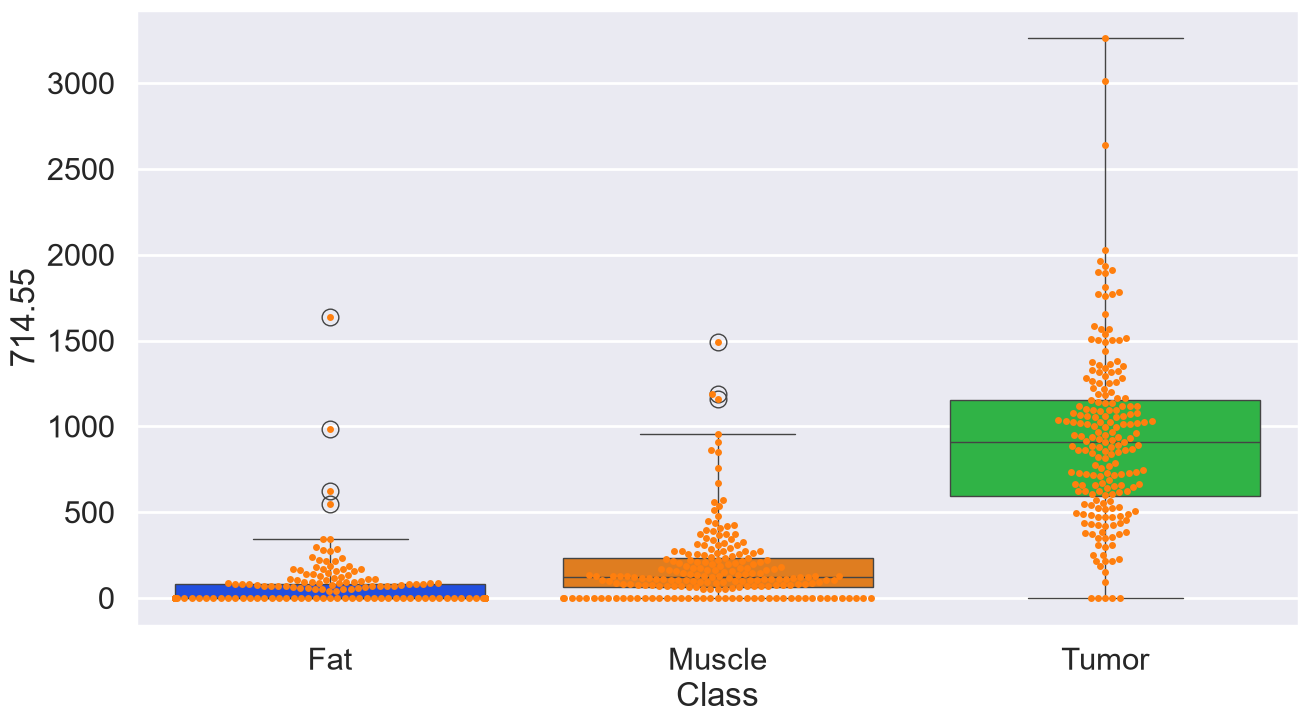

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 73.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 67.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 72.5% of the points cannot be placed; you may want to decre

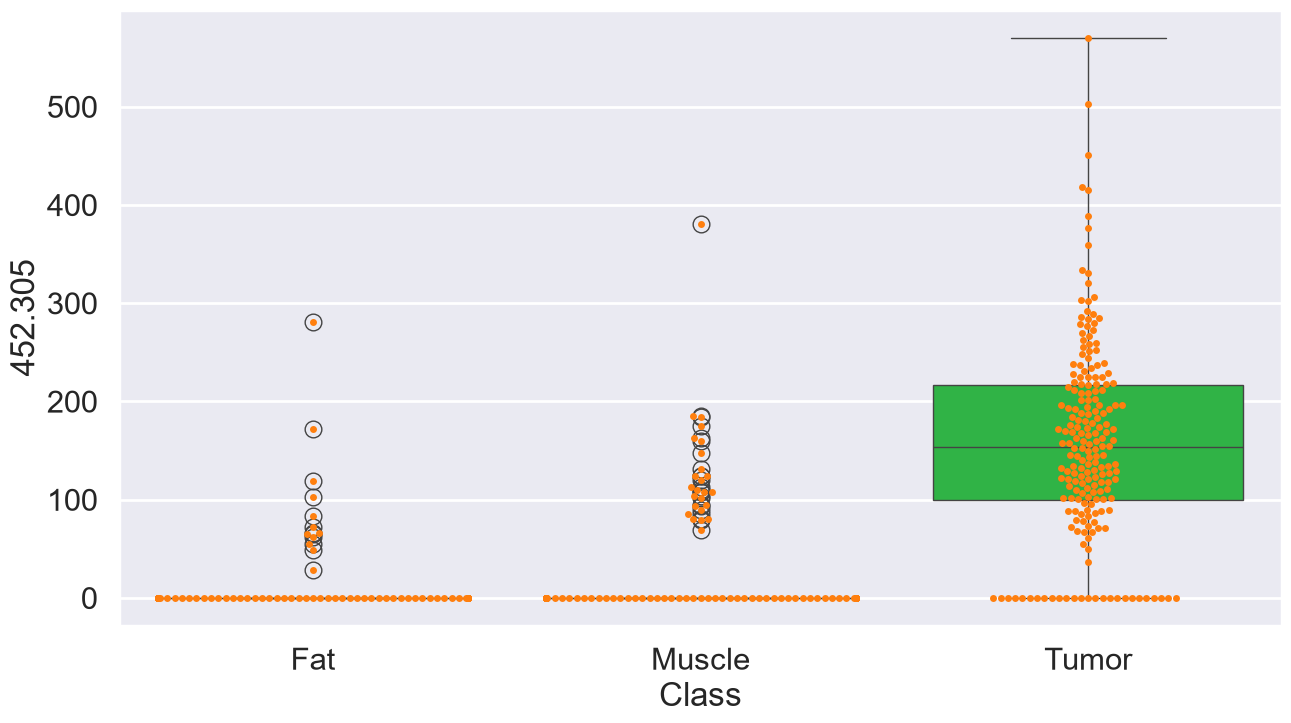

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 33.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


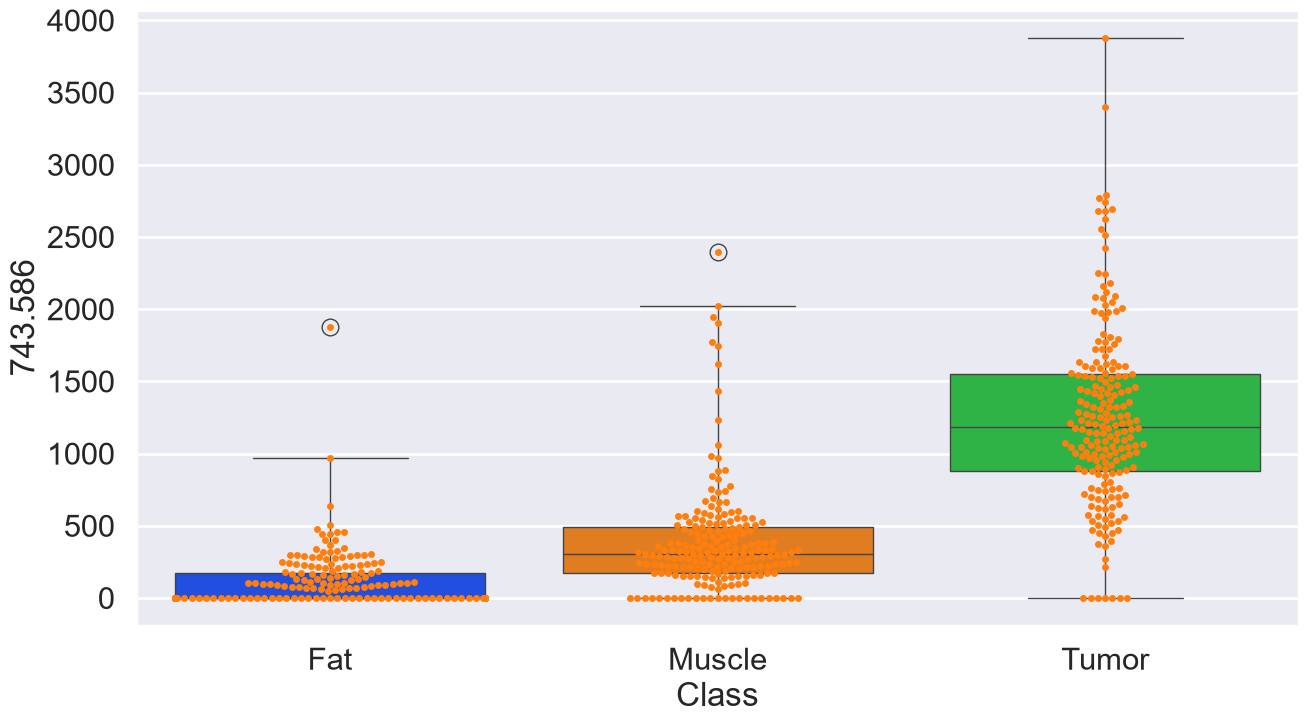

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 53.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 52.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


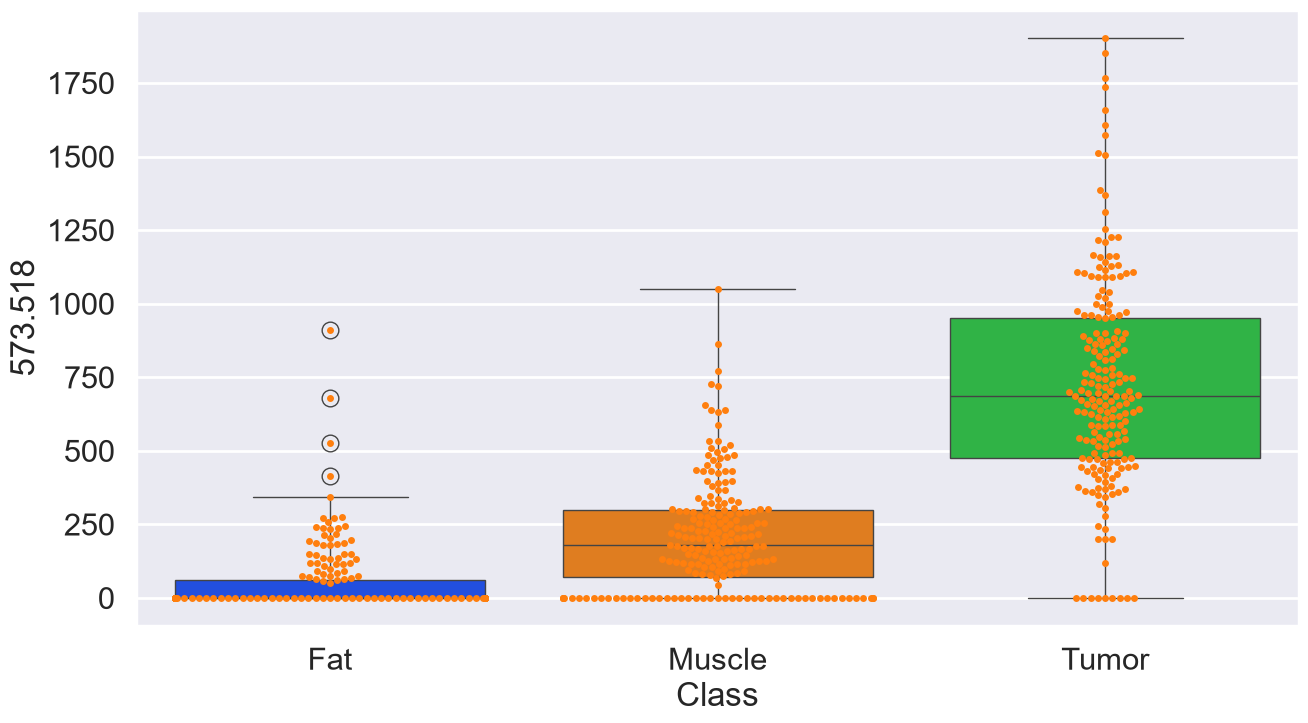

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 56.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 33.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 55.5% of the points cannot be placed; you may want to decre

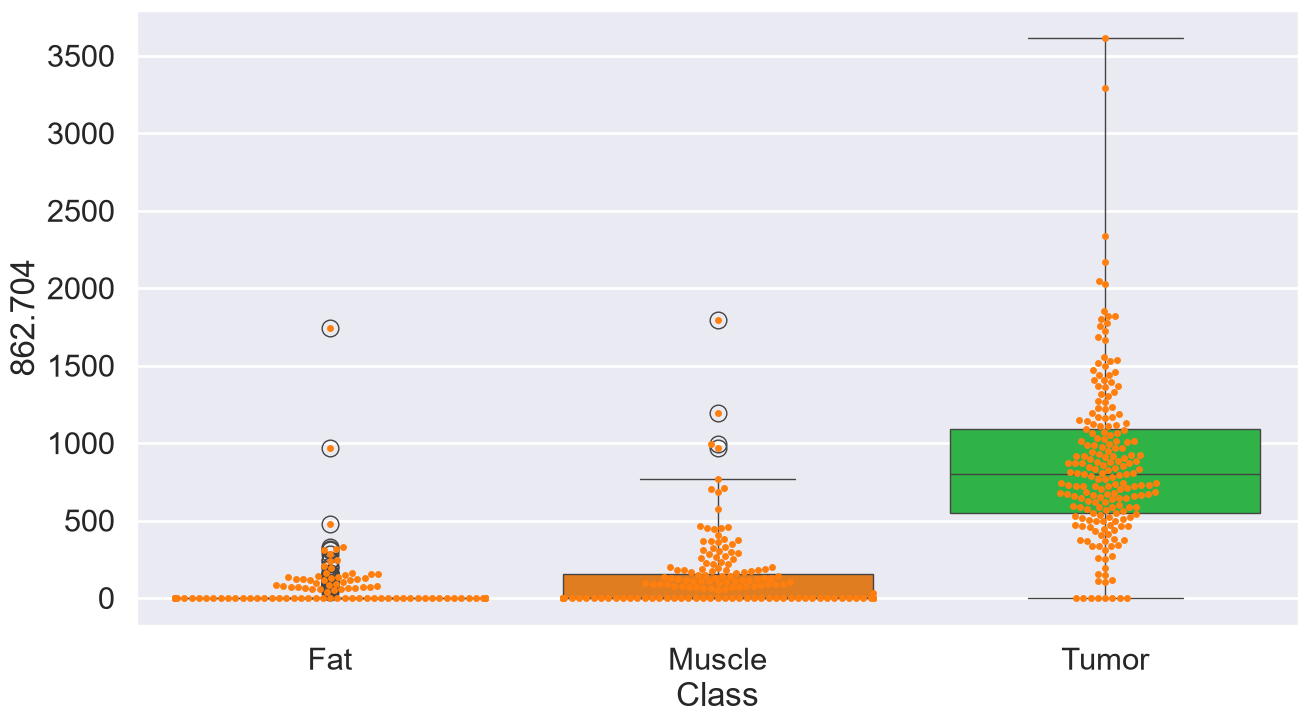

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 35.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 34.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


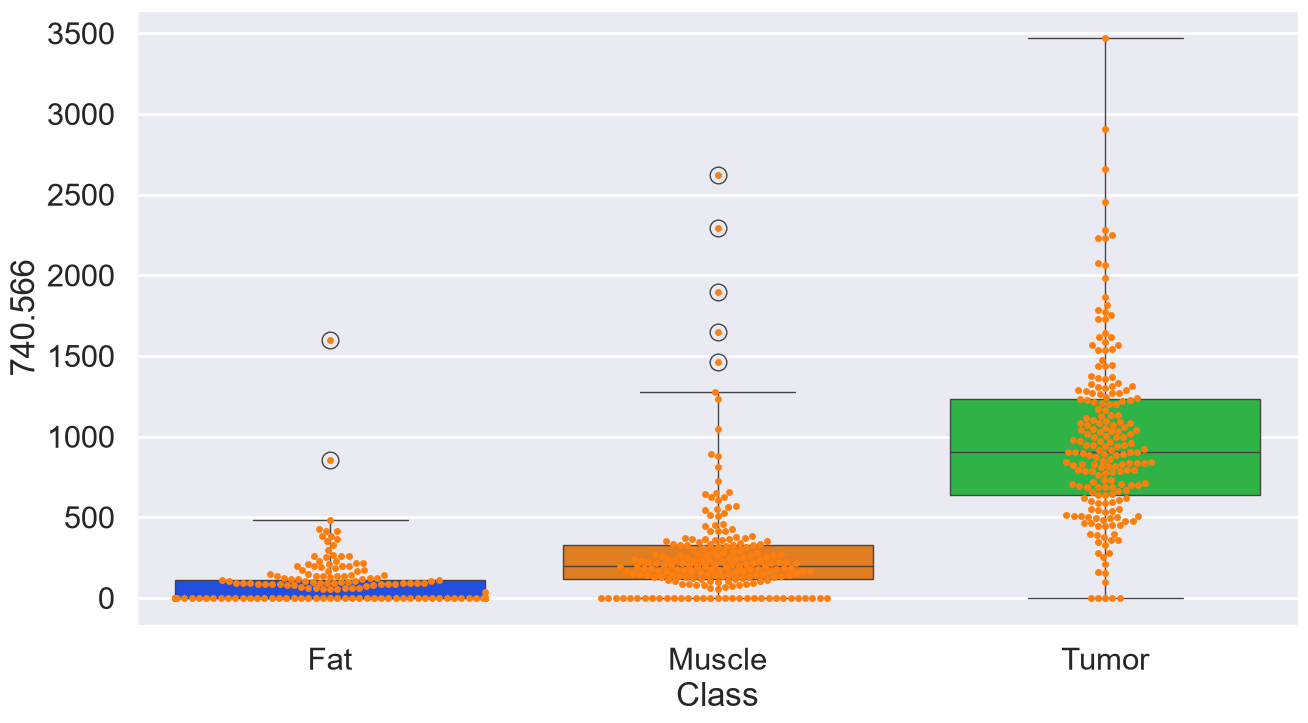

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 72.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 52.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 71.0% of the points cannot be placed; you may want to decre

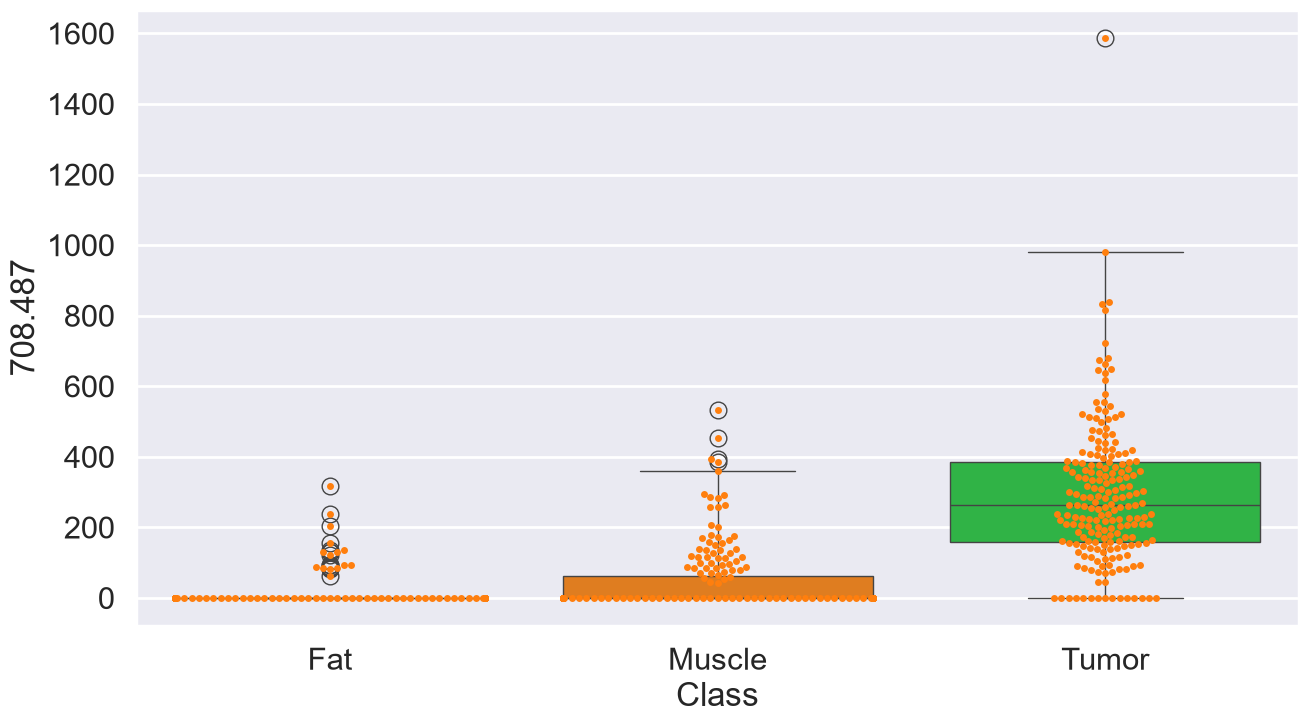

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 59.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 58.0% of the points cannot be placed; you may want to decre

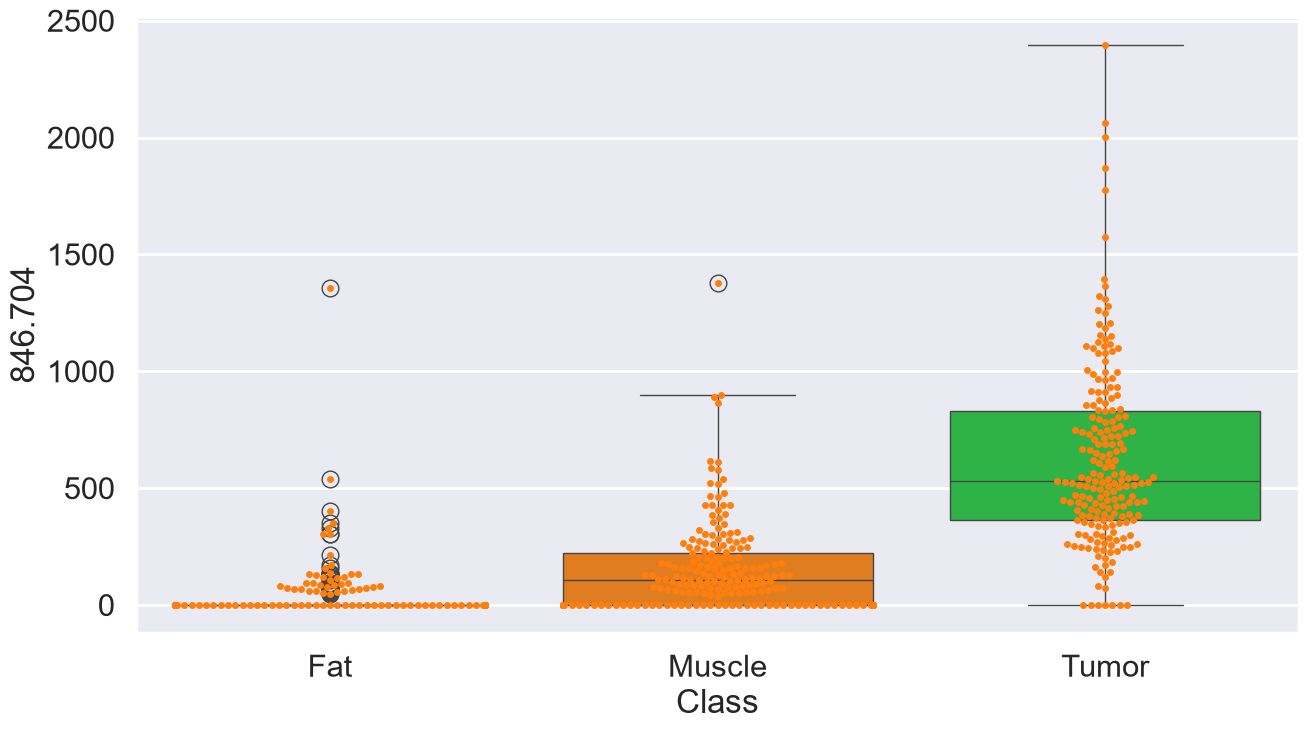

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 62.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 19.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 61.0% of the points cannot be placed; you may want to decre

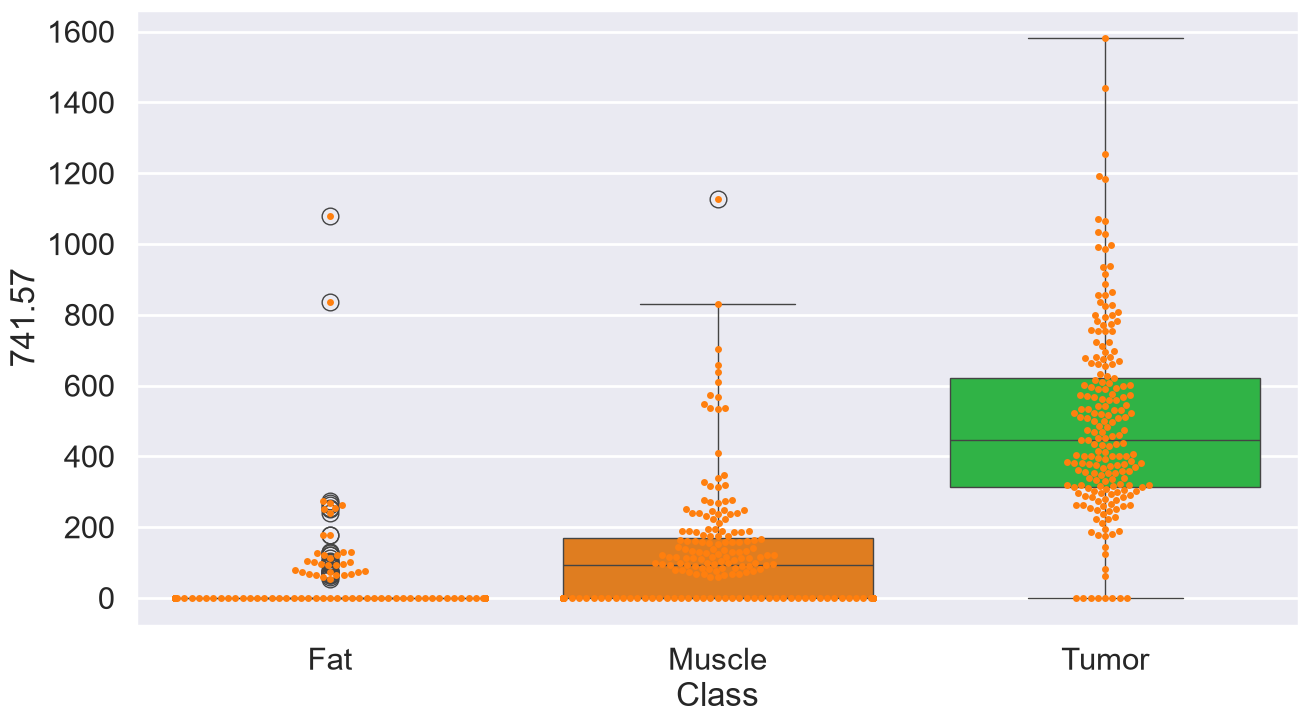

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 63.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 11.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 62.5% of the points cannot be placed; you may want to decre

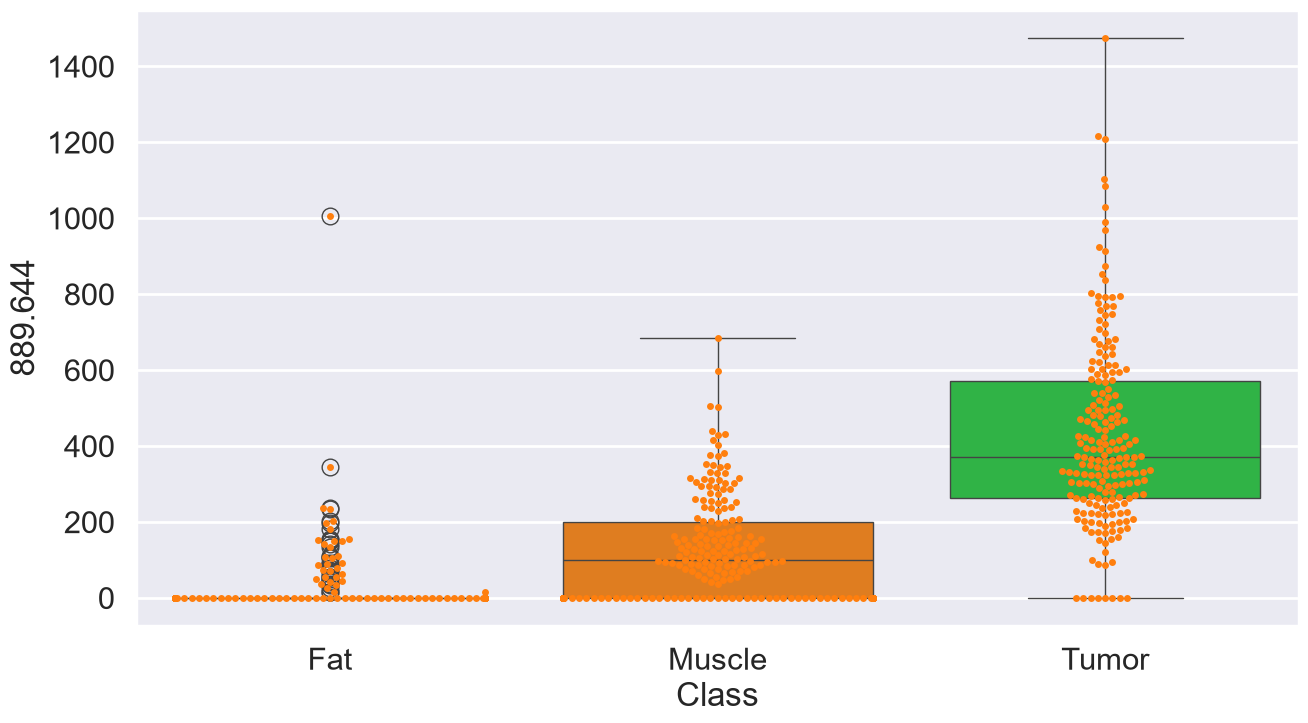

C:\Users\LocalAdmin\AppData\Local\Temp\ipykernel_32036\224571335.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_label, y=box_data.columns[index+offset], data=box_data, whis=5, palette = 'bright')
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 47.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


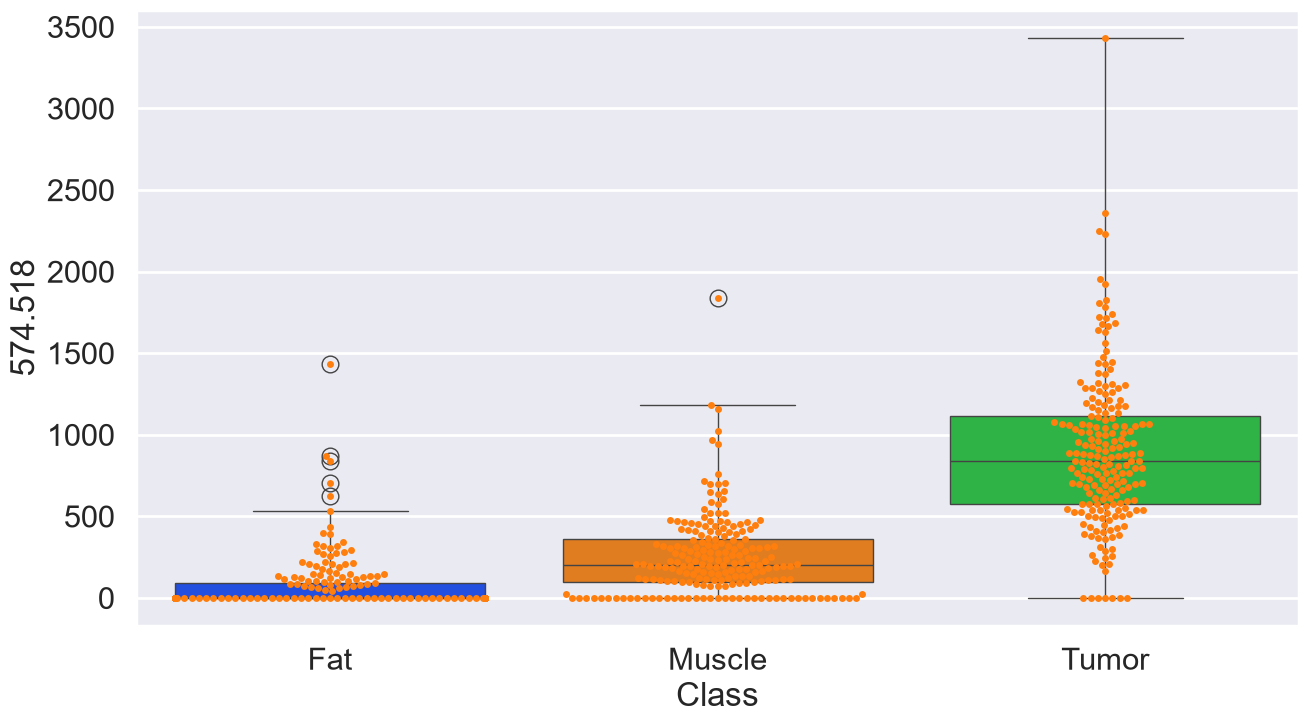

In [17]:
box_plot(KW_features.head(20)['m/z'], mz, tmp_train_sampled,'Class', save=False)

## After pretty much the same procedure, we see that the top features are now exclusively lipid-related. Can we interpret a little bit by looking at the mean spectrum of the sampled data and work out why?

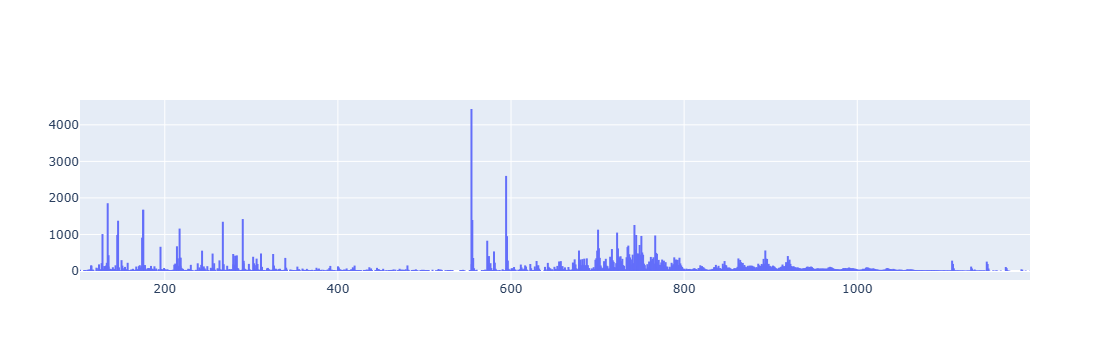

In [5]:
tic_spectrum = Data_sampled.mean(axis=0)

fig = go.Figure(go.Scatter(
    x=np.repeat(mz, 3),
    y=np.ravel(np.column_stack([np.zeros_like(tic_spectrum), tic_spectrum, np.nan * tic_spectrum])),
    mode="lines"
))

fig.show()

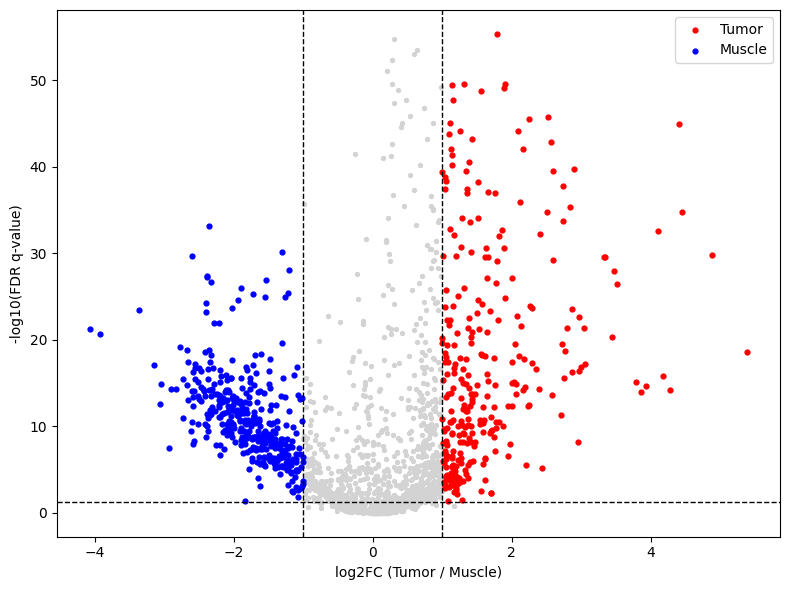

In [19]:
fc_thr = 1
q_thr = 0.05
sig = (abs(MW_result["log2FC"]) >= fc_thr) & (MW_result["q_value"] < q_thr)

up = sig & (MW_result["log2FC"] > 0)
down = sig & (MW_result["log2FC"] < 0)

plt.figure(figsize=(8, 6))
plt.scatter(MW_result["log2FC"], MW_result["-log10q"], s=8, c="lightgray")
plt.scatter(MW_result.loc[up, "log2FC"], MW_result.loc[up, "-log10q"], s=12, c="red", label=classes[1])
plt.scatter(MW_result.loc[down, "log2FC"], MW_result.loc[down, "-log10q"], s=12, c="blue", label=classes[0])

plt.axhline(-np.log10(q_thr), color="k", ls="--", lw=1)
plt.axvline(fc_thr, color="k", ls="--", lw=1)
plt.axvline(-fc_thr, color="k", ls="--", lw=1)

plt.xlabel(f"log2FC ({classes[1]} / {classes[0]})")
plt.ylabel("-log10(FDR q-value)")
plt.legend()
plt.tight_layout()
plt.show()

# Data Interpretation Part 2

## Now we are very experienced with univariate analysis of MSI data, let's take the multivariate approach, in the form of a SVM classifier:

In [10]:
column = Label_sampled
group = Label_sampled

labelnames = list(np.unique(column))
w = np.array([(column==c).sum() for c in labelnames])
weights = {c: w.max()/n for c,n in zip(labelnames,w)}

Data_n = data_norm(Data_sampled,'tic')
Data_log = data_norm(Data_n,'log')

[results,model] = train_cv(
    Data_log,
    method="SVM",
    cvsplit="kfold",
    label=column.tolist(),
    group=group.tolist(),
    weights=weights
)

C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter

Method SVC(class_weight={'Fat': np.float64(1.0), 'Muscle': np.float64(1.0),
                  'Tumor': np.float64(1.0)},
    decision_function_shape='ovo', kernel='linear', probability=True) iteration 0 
that took 3.9048986434936523 seconds


## Here we are doing a k-fold CV approach, let's see how the training/validation splits actually work:

<Axes: title={'center': 'StratifiedKFold'}, xlabel='Sample index', ylabel='CV iteration'>

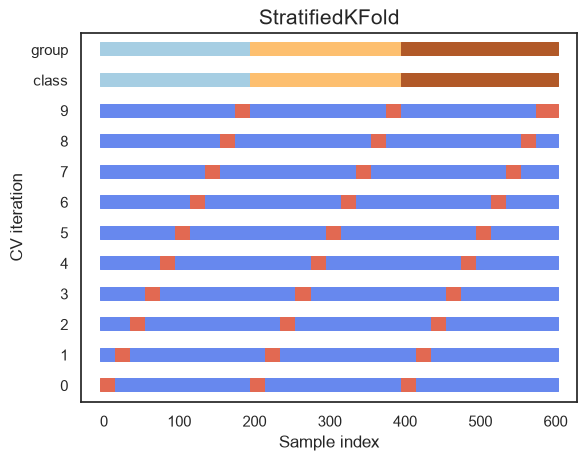

In [33]:
# k-fold plot
cvsplit = StratifiedKFold(n_splits=10)
old_label = Label_sampled.to_numpy()
old_group = Label_sampled.to_numpy()

sns.set_context("notebook")
sns.set_style("white")
plot_cv(cvsplit, Data_log, old_label, old_group, 10, lw=10)

## Let's see the results by means of a **confusion matrix**:

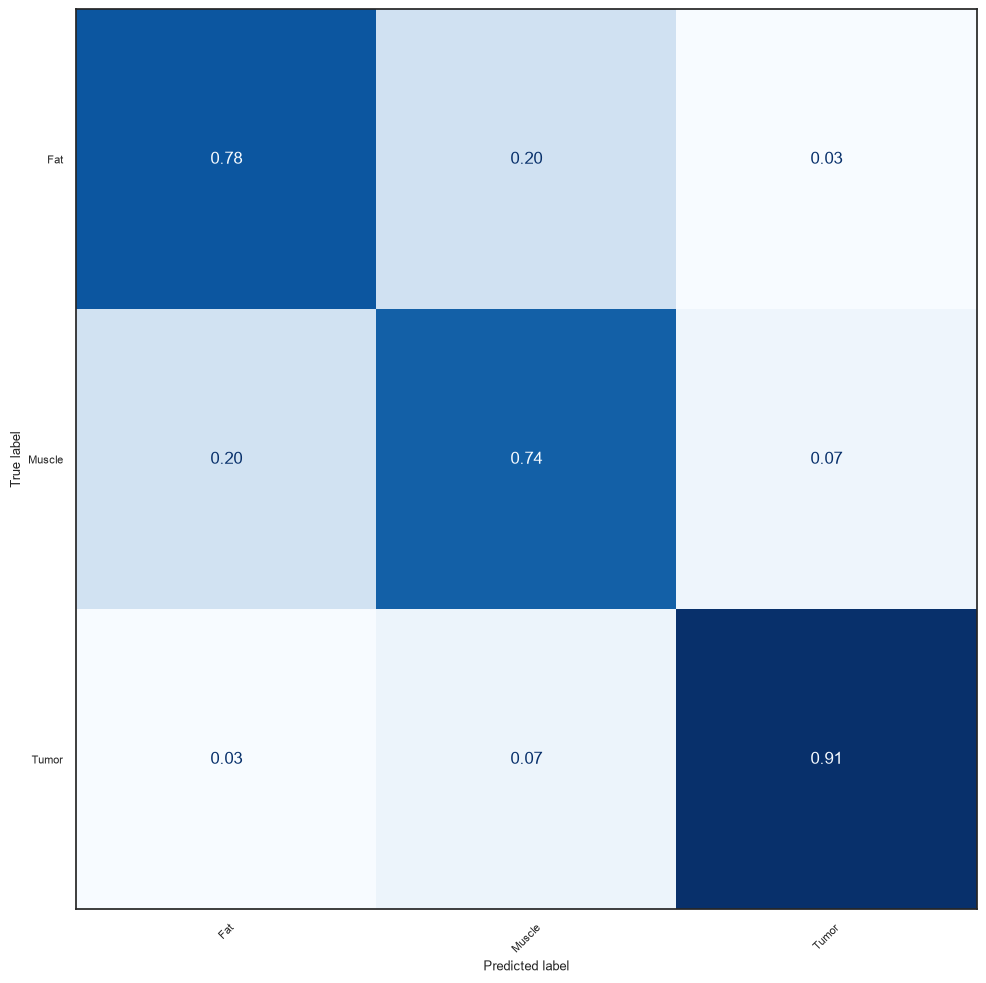

In [27]:
pred = results.iloc[:,0]
cm_label = np.unique(column)
CM = confusion_matrix(column, pred, normalize="true")

fig,ax = plt.subplots(figsize=(10,10))
disp = ConfusionMatrixDisplay(CM, display_labels=cm_label)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
ax.set_xlabel("Predicted label", fontsize=9)
ax.set_ylabel("True label", fontsize=9)
plt.tight_layout()
plt.show()

# print(classification_report(column, pred))


## Let's look at a numerical summary of the performance results

In [28]:
performance = calculate_FPASS(CM, cm_label)
performance

,class,accuracy,sensitivity,specificity,precision,F1
0,Fat,0.8325,0.775,0.89,0.778894,0.776942
1,Muscle,0.8025,0.74,0.865,0.732673,0.736318
2,Tumor,0.93,0.905,0.955,0.909548,0.907268
3,Average,0.855,0.806667,0.903333,0.807038,0.806843


## What about the ROC curve:

C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\LocalAdmin\anaconda3\envs\TUMD4\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter

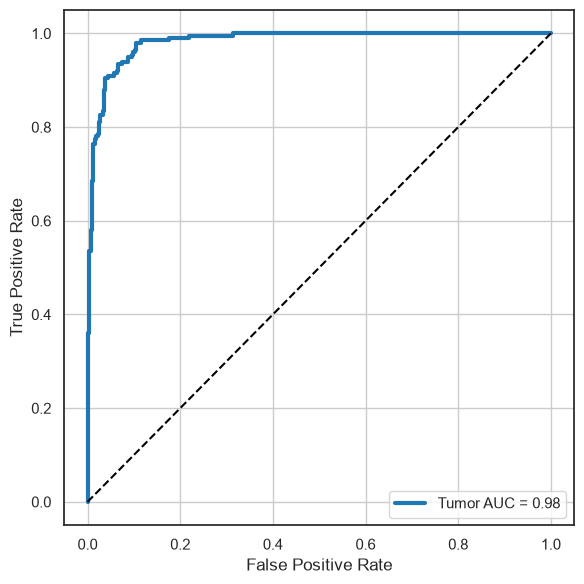

In [32]:
X = Data_log.values if hasattr(Data_log,"values") else Data_log
y = column.values

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
clf = SVC(probability=True, kernel="linear", class_weight="balanced")

probs = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")

classes = np.unique(y)
pos = classes[2]

fpr,tpr,_ = roc_curve(y, probs[:,2], pos_label=pos)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,lw=3,label=f"{pos} AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Here we see that the Tumour AUC is a lot higher than the calculated metrics from above, can you see why?

## Feature selection by importance

## Just as in the univariate analysis section, we want to know what is driving the (good) classification i.e., biomarker discovery, in a multivariate picture, this is much faster, as we can simply look at the importance metric from the classification model we have already constructed, let's see the top 30 features:

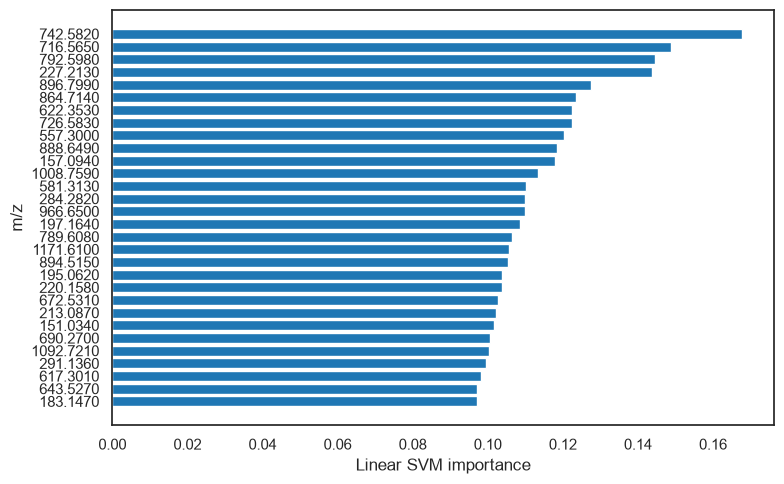

In [21]:
topn = 100
X = Data_log.values if hasattr(Data_log,"values") else Data_log
y = Label_sampled.values

svm = LinearSVC(class_weight="balanced", dual=False, max_iter=10000).fit(X, y)
SVM_importance_score = np.abs(svm.coef_).max(axis=0) if np.ndim(svm.coef_) > 1 else np.abs(svm.coef_)

SVM_plot = pd.DataFrame({
    "mz": mz,
    "importance": SVM_importance_score
})

SVM_plot = SVM_plot.sort_values("importance", ascending=False).head(topn)

plt.figure(figsize=(8, 5))
plt.barh(SVM_plot.head(30)["mz"].map(lambda x: f"{x:.4f}"), SVM_plot.head(30)["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Linear SVM importance")
plt.ylabel("m/z")
plt.tight_layout()
plt.show()

## Let's see if features make sense

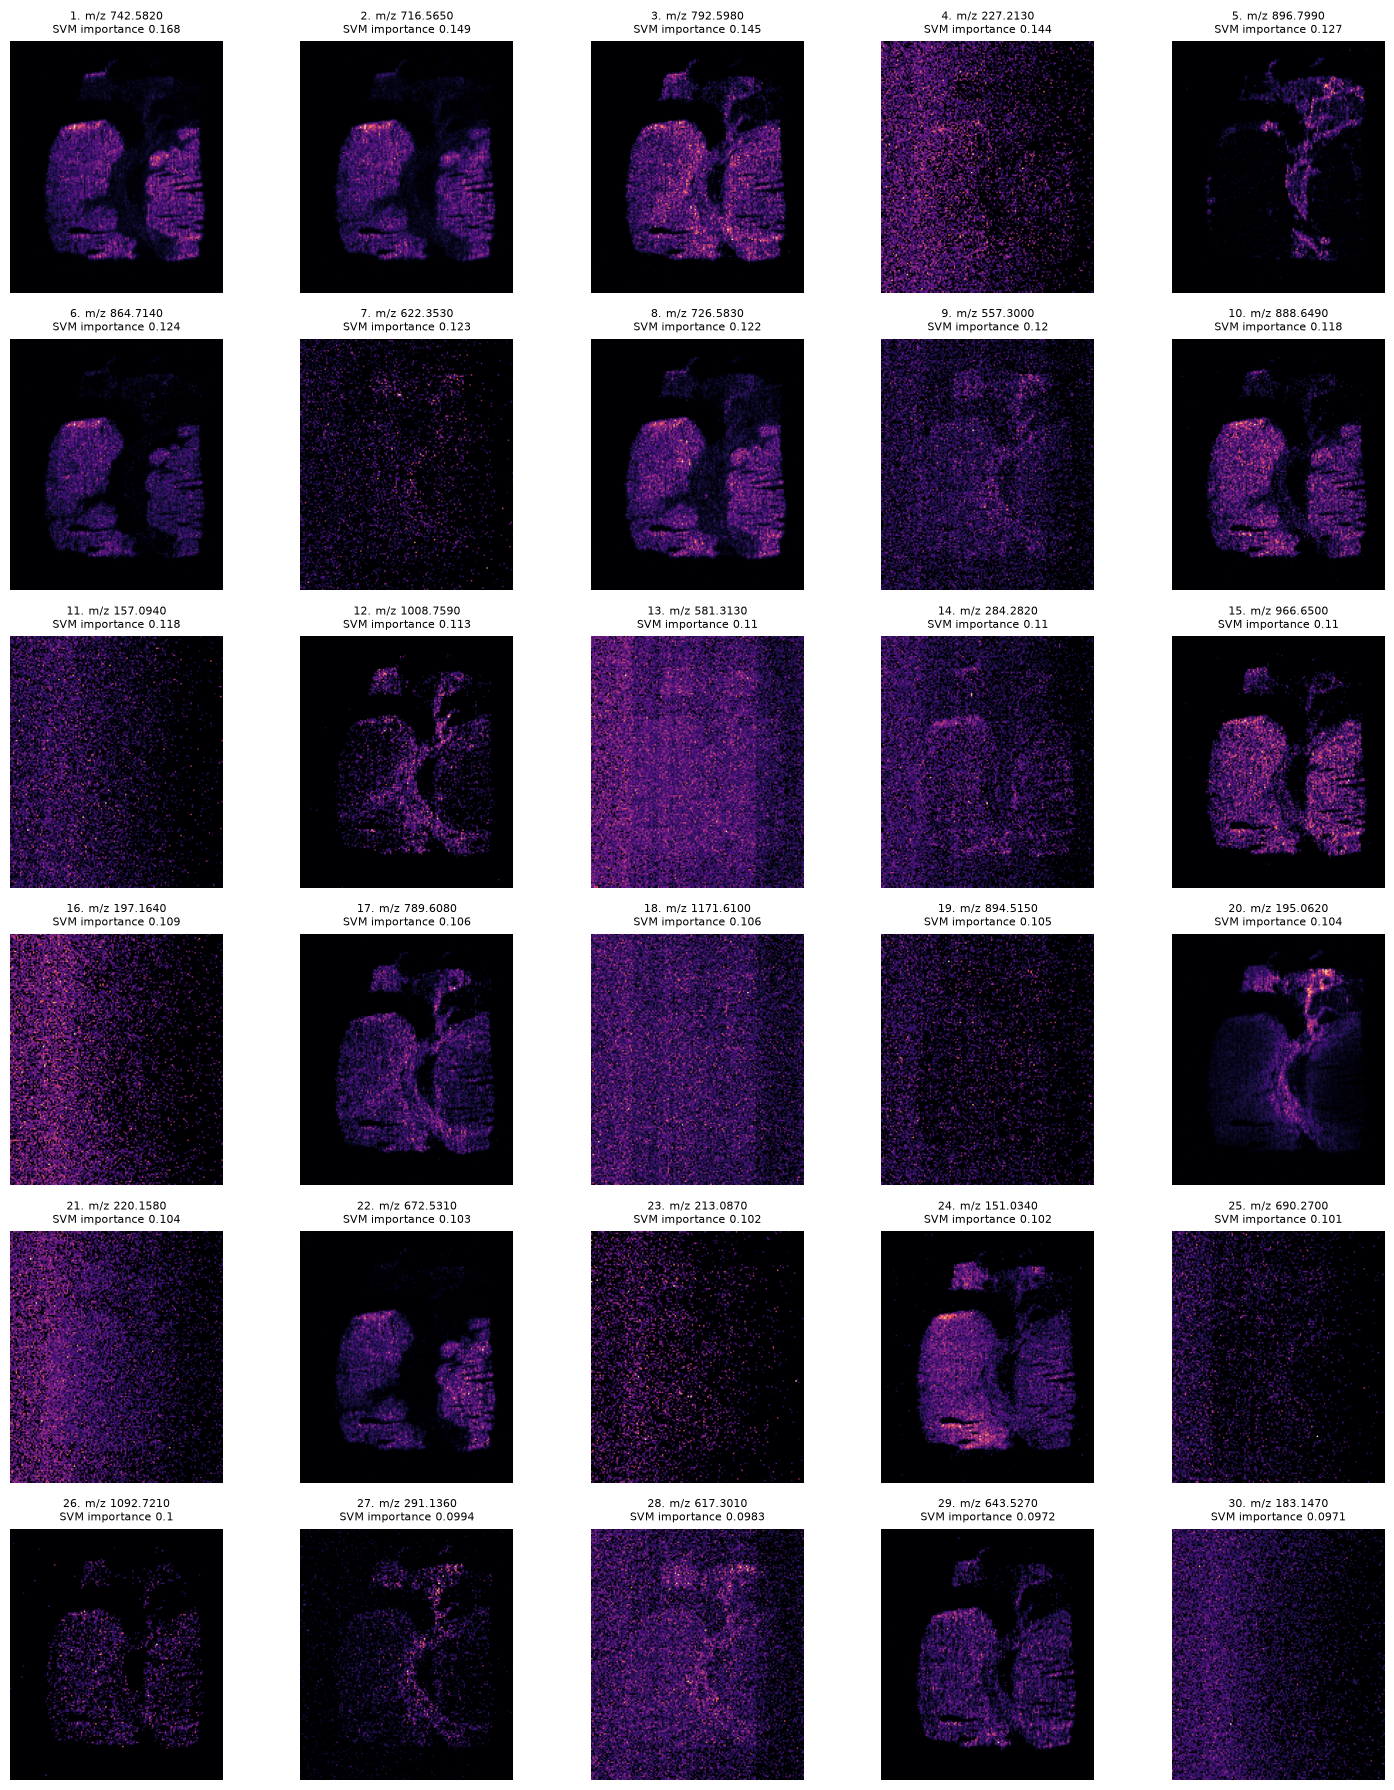

In [12]:
# Feature-column indices ranked by SVM importance: highest first.
SVM_idx = np.argsort(SVM_importance_score)[-topn:][::-1]

fig, axes = plt.subplots(6, 5, figsize=(15, 18))
axes = axes.ravel()

xy_plot = (
    tmp_train_sampled["Sample"]
    .str.extract(r"pixel_(\d+)_(\d+)")
    .astype(int)
    .to_numpy()
)
for rank, (ax, feature_idx) in enumerate(zip(axes, SVM_idx), start=1):
    plot_xic(
        target_mz=mz[feature_idx],
        data=Data_train,
        max_x=150,
        max_y=177,
        ax=ax,
        add_colorbar=False
    )

    ax.set_title(
        f"{rank}. m/z {mz[feature_idx]:.4f}\n"
        f"SVM importance {SVM_importance_score[feature_idx]:.3g}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

## Mostly, but again we may have an issue with background signal. We can easily go back to the tissue masking approach from before, you can try this yourself.

## In the meantime, let's conclude by summarising the feature overlap between univariate and multivariate analyses and see what we can learn:

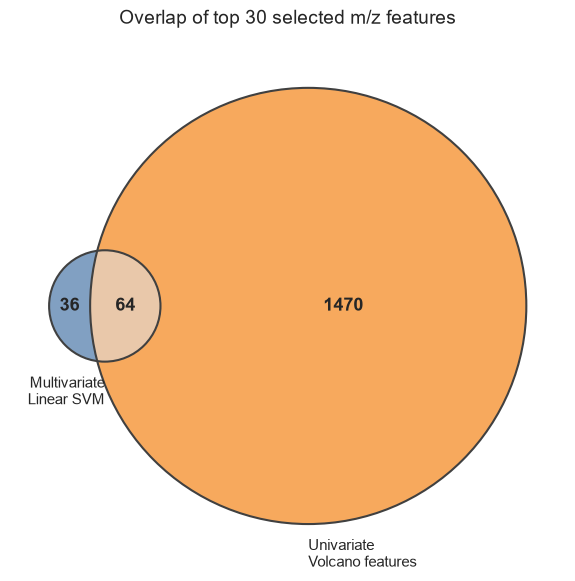

In [22]:
from matplotlib_venn import venn2, venn2_circles

topn = 30

# Feature identity is defined at four decimal places.
svm_mz = set(
    np.round(SVM_plot["mz"].to_numpy(dtype=float), 4)
)

univariate_mz = set(
    np.round(vol_features["m/z"].to_numpy(dtype=float), 4)
)

fig, ax = plt.subplots(figsize=(7, 6))

venn = venn2(
    subsets=(svm_mz, univariate_mz),
    set_labels=(
        "Multivariate\nLinear SVM",
        "Univariate\nVolcano features"
    ),
    set_colors=("#4C78A8", "#F58518"),
    alpha=0.70,
    ax=ax
)

# Add circle outlines for a cleaner figure.
venn2_circles(
    subsets=(svm_mz, univariate_mz),
    linewidth=1.5,
    color="#404040",
    ax=ax
)

# Optional: customize count-label font size.
for subset_id in ("10", "01", "11"):
    label = venn.get_label_by_id(subset_id)

    if label is not None:
        label.set_fontsize(13)
        label.set_fontweight("bold")

# Optional: customize the two method labels.
for label in venn.set_labels:
    if label is not None:
        label.set_fontsize(11)

ax.set_title(
    f"Overlap of top {topn} selected m/z features",
    fontsize=14,
    pad=18
)

plt.tight_layout()
plt.show()

In [40]:
vol_mz_rounded = np.round(
    vol_features["m/z"].to_numpy(dtype=float),
    4
)

overlap_mask = np.isin(vol_mz_rounded, list(svm_mz))
overlap_features = (
    vol_features
    .loc[overlap_mask]
    .copy()
)
overlap_features = overlap_features.drop(columns=['-log10q'])
out_file = "selected_mz_features_overlap.csv"
overlap_features.to_csv(out_file, index=False)
overlap_features

,m/z,p_value,log2FC
1528,782.638,1.393676e-31,5.727920
1655,862.638,9.456412e-34,5.165940
1582,818.674,3.538176e-75,4.994711
1228,672.531,1.080740e-81,4.614997
1404,735.578,9.420592e-64,4.333235
...,...,...,...
1704,890.758,6.653205e-06,-1.782625
1702,889.759,5.412875e-15,-2.445570
1719,896.799,1.143261e-20,-2.609489
1572,811.706,1.270070e-22,-3.420426
